# 03 - Back-EMF constant, three ways

## Purpose

This notebook is the third in the series. It measures the back-EMF constant
$K_e$ of the motor, the voltage the winding generates per unit of speed, by
routes that rest on different physics and different samples of the same
hardware, and it examines a candidate channel that the data rejects.

The jobs:

1. Measure $K_e$ against a speed the **pot never touches** (section 8). The
   motor's own commutation ripple is the tachometer: the drive current
   carries six cycles per motor revolution, and the coast that follows the
   drive carries the open-circuit back-EMF. This is the primary route, and
   it is the one whose answer repeats.
2. Measure $K_e$ by the two pot-referenced routes of the earlier runs, the
   drive grid (section 5) and the coast decay (section 7), and show why
   both are biased low and scatter (section 8.2).
3. Characterize the direct back-EMF channels: the fast-decay crest sample
   in the drive grid (section 6, rejected) and the coast terminals
   (section 7), and contrast coast against brake (section 7.6).
4. Record the spread of every estimate, and end with what is still open
   and what experiment would close it (sections 9 to 12).

**The dataset is 2S.** Every coefficient below comes from the 2-cell
battery dataset `sg90-a__dev-v006-D__2s`. The USB dataset appears once, in
section 8.3, as a check that a trend points the same way. It is never a
source, because the USB rail droops 3.5% across the duty range and dips
22% on spin-up, so anything fitted against duty on USB folds rail droop
into the duty axis.

Two units are in play, and keeping them apart is the point of this run.
The **motor-referenced** constant is millivolts per motor revolution per
second, and needs no pot at all. The **pot-referenced** constant is volts
per wiper volt per second, as in notebooks 00 and 01. Converting between
them needs the gear ratio (counted, exact) and the pot scale (disputed by
9%), so section 8.2 carries both readings of the pot scale rather than
picking one.

## 1. Test setup

The device under test and the signal chain are those of notebook 00: an
SG90-class hobby servo with replacement electronics, a brushed DC motor
behind an H-bridge at 20 kHz PWM, a pot wiper on the output shaft read
directly by the 12-bit ADC, a shunt in the motor return path with a
fixed-gain amplifier, and both motor terminals read through dividers whose
bottom legs return to a bias node $V_B$, so a terminal below ground still
reads inside the ADC range. The parts are declared in `oscnb/boards.py`
and printed by section 2; nothing is written down twice.

Three facts about this run differ from the earlier ones and matter
throughout.

- **The supply is a 2-cell battery.** The rail at the driven terminal is
  7.72 to 7.76 V and rises, not falls, with duty. The earlier runs used a
  laptop USB port at 4.4 to 4.6 V that sagged by more than a volt during a
  full-duty inrush. Every applied voltage below is still built from the
  terminal readings of the same samples it is paired with, so no nominal
  rail enters anywhere.
- **The ADC is clocked at 24 MHz.** The earlier build ran it at 48 MHz and
  skipped a band of codes below several binary boundaries, which forced an
  interpolation workaround in the earlier run of this notebook. Section 4.3
  re-runs the same scan on this data and finds the defect gone, so the
  workaround is deleted rather than carried.
- **The drive windows are sized by travel.** Each rung of the grid runs
  long enough to cover about 2554 counts of the pot's runway at that duty,
  from 1500 ms at 5% down to 124 ms at 100%, where the earlier grid used a
  flat 80 ms. The steps below therefore reach a settled speed inside the
  window at every duty this notebook fits.

Two facts about the bridge matter here.

- During the ON portion of a PWM period the bridge connects one terminal to
  the supply and the other to ground through the shunt.
- During the OFF portion the bridge has two modes. **Slow decay** closes
  both low-side switches and shorts the winding, so both terminals sit near
  ground and the winding current keeps circulating. **Fast decay** opens all
  four switches. The winding current then returns to the supply through the
  body diodes, during which the terminal that carries the current out of the
  winding sits one diode drop above the supply, the other sits one diode
  drop below ground, and the shunt reads negative. Once the current reaches
  zero the winding floats and the terminals carry the open-circuit back-EMF.

A **coast** segment is fast decay held at zero duty, so the winding floats
for the whole segment. A **brake** segment is slow decay at zero duty, so
the winding stays shorted. Back-EMF is readable only during a genuine
coast: section 7.6 measures what brake leaves on the terminals, and it is
4% of the coast reading, which is $i R_{ds}$ and not an EMF.

Each sample row carries a shunt reading and both terminal readings taken at
one fixed point of the PWM period, the **crest scan**, plus a second shunt
reading from the opposite point of the period, the **trough scan**. Under
slow decay the crest scan falls inside the ON portion once the drive width
reaches the firmware's threshold, and the firmware marks those samples
valid. Under fast decay the crest scan falls in the OFF portion (notebook
01, section 5.3).

**The board is a hacked rig.** The board under this dataset is a
development board reworked by hand several times (the shunt, the dividers,
the bias return, the reservoir capacitors, a repaired amplifier pad). Its
one defect that reaches this notebook is that the bus telemetry stream
couples into the current amplifier's output, so a shunt sample taken while
a frame is going out on the wire can read a few counts off. On the scan
geometry of this firmware build it does not show at rest (notebook 00,
section 5.2) and it is worth a few mA at the currents here, which is
negligible for $R$ and for $K_e$. It is a limitation of this board and is
not coded around anywhere.

### 1.1 Model and routes

The winding obeys

$$v = R\,i + L\,\frac{di}{dt} + K_e\,\omega$$

with $v$ the terminal voltage, $i$ the winding current, $R$ the winding
resistance (brushes included), $L$ the winding inductance, $\omega$ the
speed and $K_e$ the back-EMF constant. Averaged over one PWM period the
inductive term is negligible on the millisecond scale of a drive step.
Under slow decay the OFF portion applies zero volts, so the mean terminal
voltage is the duty times the ON-portion terminal difference:

$$\bar v = D\,(v_{\mathrm{drv}} - v_{\mathrm{idle}}) = R\,\bar i + K_e\,\bar\omega$$

The equation is linear, so it holds for the means over any window of a
step, steady or not, as long as all three means come from the same window.
With the winding open, $i = 0$ and the terminal difference equals
$K_e\,\omega$ directly.

- **Route A** uses slow-decay drive steps. The mean voltage, mean current
  and mean speed over the last 60% of every valid step are fitted to the
  averaged equation, with $R$ anchored from the first milliseconds of the
  full-duty steps, before the mechanism has gathered speed. Speed comes
  from the pot.
- **Route C** uses the coast segments. The floating terminal difference is
  regressed on the instantaneous speed as the mechanism spins down. Speed
  comes from the pot.
- **Route R** uses the same coast segments for the back-EMF, but takes the
  speed from the commutation ripple in the drive current that preceded the
  coast. The pot is never read. This is the route that closes.
- The **fast-decay crest sample**, one terminal reading per PWM period
  taken in the OFF portion, is the candidate for a direct back-EMF channel
  inside a drive step. Section 6 tests it against speed and current and
  rejects it.

Route A shares nothing with C and R beyond the terminal dividers. Route C
and route R share the back-EMF sample and differ only in where the speed
comes from, which is exactly the comparison section 8.2 needs.

## 2. Constants and unit conversions

Nothing about the hardware is written down in this notebook. The
measurement chain (shunt, divider legs, amplifier gain, VDD, bias network,
sample rate) lives in `oscnb/boards.py` and the mechanism (gear ratio,
ripple order, pot mapping, travel) in `oscnb/servos.py`. A dataset's
`manifest.json` names which board and which servo produced it, and reading
a recording checks its own `sense` block against that board, so a dataset
pointed at the wrong hardware fails at load rather than quietly producing
numbers off by the ratio of two shunts.

The cell below selects the dataset and prints what that selection means:
the derived conversions (what the hardware is) and the measured values
(what somebody found when they looked, each with its bracket and source).

With the divider's bottom leg returned to the bias $V_B$, a terminal
voltage $V_t$ reaches the ADC pin as

$$\text{tap} = \frac{V_t}{r} + \frac{r - 1}{r} V_B, \qquad V_t = r\,\text{tap} - (r - 1)\, V_B, \qquad r = \frac{R_\text{top} + R_\text{bot}}{R_\text{bot}}$$

so `board.term_v(tap, vb)` is the second form and `board.v_term_per_count`
is $r$ times the converter step, the terminal volts carried by one count of
tap **difference**.

The **difference** of the two terminals is where this notebook lives, in
the applied voltage of route A and in the back-EMF of routes C and R. A
floating winding at rest has no voltage across it, so the difference must
read zero at rest whatever the two taps read. Every difference below is
therefore taken relative to each tap's own rest reading:

$$V_a - V_b = r\,\big[(\text{tap}_a - \text{tap}_{a,\mathrm{rest}}) - (\text{tap}_b - \text{tap}_{b,\mathrm{rest}})\big]$$

Section 4.2 checks that the split at the end of every coast, with the
winding floating and the mechanism at rest, is the same as in the
baseline, which is what makes this the right zero. Section 7.5 shows what
the other two readings of the split would do to route C.

Three caveats:

- The ADC reference is the chip's VDD supply, taken at its design value.
  Every voltage below scales linearly with the true VDD. $K_e$ is a ratio
  of a terminal voltage to a speed, and the motor-referenced form of
  section 8 has no VDD in its speed at all, so only the terminal voltage
  scales. $R$ scales as a ratio of two VDD-referenced readings, so it does
  not.
- The divider, shunt and gain are design values. Component tolerances were
  not measured, and absolute voltages and currents carry them.
- $V_B$ enters only the absolute terminal voltages. A 1-count error in it
  moves an absolute terminal reading by $r - 1$ counts, under 2 mV.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, welch, detrend

import oscnb

# 2S IS PRIMARY. Every coefficient in this notebook comes from this dataset. The USB
# dataset appears only in section 8.3, as a check that a trend points the same way: its
# rail droops 3.5% across the duty range and dips 22% on spin-up, so a fit against duty
# on USB folds rail droop into the duty axis.
ds = oscnb.use("sg90-a__dev-v006-D__2s")
board, servo = oscnb.current().board, oscnb.current().servo

TICK_HZ = board.tick_hz      # 20 kHz, one telemetry sample per control tick
Q15 = 32767                  # duty full scale as encoded on the wire

dataset  sg90-a__dev-v006-D__2s
supply   2s
rig      SG90 clone, unit A on osc-dev-v006 board D (bodged toward rev-2A)



,captures,recordings per capture,names
experiment,,,
breakaway,5,1,sweep
bridge,5,3,"fast, slow, spindown"
grid,10,1,sweep
reversal,5,1,sweep
ripple,5,1,sweep
stepcoast,5,5,"step120, step20, step40, step60, step80"



derived constants (what the hardware is)


value
where            quantity                                           unit                         
board            converter step                                     mV per count           0.8057
                 terminal divider ratio r                                                  3.0606
                 terminal difference                                mV per count           2.4658
                 terminal bias VB                                   mV                   627.9352
                                                                    counts               779.4008
                 driven-low terminal reads                          counts               524.7451
                 motor current                                      mA per count           0.8952
                                                                    counts per A        1117.0909
                 shunt                                              mOhm                  60.0000
                 amplifier gain                                     x                     15.0000
                 rail tap ratio                                                            2.5000
                 sample rate                                        samples per ms        20.0000
                 current settled from (UNVERIFIED)                  % duty                13.3333
                 voltage settled from (UNVERIFIED)                  % duty                13.3333
servo            pot intercept                                      counts               232.0000
                 pot slope                                          counts per degree     19.9600
                 envelope low                                       counts (10 deg)      431.6000
                 envelope high                                      counts (170 deg)    3625.2000
                 runway                                             counts              3193.6000
                 seek guard low                                     counts               432.0000
                 seek guard high                                    counts              3625.0000
servo (measured) gear_ratio_measured [234.73, 234.73] mechanical... :1                   234.7300
                 ripple_order_measured [6, 6] bringup isns-diff ... per motor rev          6.0000
                 kv_measured [7880, 8040] bringup isns-diff run28   RPM/V               7960.0000
                 kt_measured [1.19, 1.21] bringup isns-diff run28   mN-m/A                 1.2000
                 r_motor_measured [4.16, 4.24] bringup isns-diff... Ohm                    4.2000
                 l_motor_measured [0.45, 0.55] bringup isns-diff... mH                     0.5000
                 stall_current_measured [1.45, 1.55] bringup isn... A                      1.5000
                 stall_torque_measured [1.75, 1.85] bringup isns... mN-m                   1.8000
                 free_run_current_measured [0.078, 0.084] bringu... A                      0.0810
                 r_winding_measured [4.3, 4.8] nb03, full duty o... Ohm                    4.5000
                 pot_scale_measured [18.07, 18.49] ripple tach v... counts/deg            18.2900
                 coast_bemf_slope_measured [0.19, 0.204] nb01, c... V per wiper V/s        0.1970
                 ke_measured [7.29, 7.49] ripple speed + coast B... mV per motor rev/s     7.3670


measured values (what someone found when they looked)


value                 unit           bracket  \
where quantity                                                            
board vb_bias            781.000               counts        [775, 783]   
      rail_droop_usb      -3.500  % over 20-100% duty          [-4, -3]   
      opa_noise_floor      2.200           counts RMS          [2, 2.4]   
      esd_clamp_skew       1.800               V bemf        [1.7, 1.9]   
servo gear_ratio         234.730                   :1  [234.73, 234.73]   
      ripple_order         6.000        per motor rev            [6, 6]   
      kv                7960.000                RPM/V      [7880, 8040]   
      kt                   1.200               mN-m/A      [1.19, 1.21]   
      r_motor              4.200                  Ohm      [4.16, 4.24]   
      l_motor              0.500                   mH      [0.45, 0.55]   
      stall_current        1.500                    A      [1.45, 1.55]   
      stall_torque         1.800                 mN-m      [1.75, 1.85]   
      free_run_current     0.081                    A    [0.078, 0.084]   
      r_winding            4.500                  Ohm        [4.3, 4.8]   
      pot_scale           18.290           counts/deg    [18.07, 18.49]   
      coast_bemf_slope     0.197      V per wiper V/s     [0.19, 0.204]   
      ke                   7.367   mV per motor rev/s      [7.29, 7.49]   

                                                                   source  \
where quantity                                                              
board vb_bias                     Hi-Z rest baseline, 2S grid + stepcoast   
      rail_droop_usb                      2S vs USB grid, 5 captures each   
      opa_noise_floor                             bringup isns-diff run29   
      esd_clamp_skew                           bringup isns-diff findings   
servo gear_ratio                          mechanical/sg90/measurements.py   
      ripple_order                           bringup isns-diff runs 25-27   
      kv                                          bringup isns-diff run28   
      kt                                          bringup isns-diff run28   
      r_motor                                     bringup isns-diff run28   
      l_motor                                     bringup isns-diff run28   
      stall_current                               bringup isns-diff run28   
      stall_torque                                bringup isns-diff run28   
      free_run_current                            bringup isns-diff run28   
      r_winding                              nb03, full duty onset anchor   
      pot_scale         ripple tach vs counted gear ratio, 2S grid 30-...   
      coast_bemf_slope                                      nb01, chain 2   
      ke                ripple speed + coast BEMF, 2S bridge spindown,...   

                                                                   caveat  
where quantity                                                             
board vb_bias           nominal 779 from the 200/47 network, so 0.3%. ...  
      rail_droop_usb    USB also dips -21.8% transiently at 0.76 A; 2S...  
      opa_noise_floor   arm-B external network at G15; the internal PG...  
      esd_clamp_skew    above this the A-side ESD clamp skews the divi...  
servo gear_ratio        (47*38*32*23)/(10*10*8*7), counted teeth on th...  
      ripple_order      3-segment commutator x 2 brushes; optical tach...  
      kv                bare can, +/-1% HSI scale; pinion stayed on th...  
      kt                                                                   
      r_motor           bare can. nb03 got 4.5 [4.3, 4.8] in-servo via...  
      l_motor                            locked-rotor burst, tau_e 102 us  
      stall_current                                       = V/R confirmed  
      stall_torque                                                         
      free_run_current                                         at duty 65

## 3. Capture method

Three test series from the 2S dataset, streamed at the full 20 kHz sample
rate with a CRC on every frame. Corrupted frames are dropped and counted,
so corruption turns into missing samples.

- **Slow-decay grid** (`grid/*/sweep` and `bridge/*/slow`). A one-second
  baseline with the motor undriven, then constant-duty drive steps from 5%
  to 100% in 5% increments, forward then reverse, each rung run long enough
  to cover about 2554 counts of pot travel at that duty and each preceded
  by a repositioning move toward the far end of travel at the seek duty.
  Fifteen recordings, the ten of the `grid` experiment and the five `slow`
  recordings of the `bridge` experiment, captured alongside the other two
  series.
- **Fast-decay grid** (`bridge/*/fast`). The same grid with the bridge in
  fast decay during the drive steps. Five recordings.
- **Spin-down** (`bridge/*/spindown`). A one-second baseline, then for each
  direction the sequence drive 20% for 80 ms, coast 400 ms, drive 20%,
  brake 400 ms, drive 30%, coast, drive 30%, brake, drive 40%, coast, drive
  40%, brake. Twenty-five segments per recording, five recordings. The
  zero-duty segments alternate coast and brake and are identified by their
  position in the recorded schedule.

Between recordings the servo rested with a cooldown, and one warm-up
recording per experiment was discarded.

**Data acceptance.** Any recording with a dropped frame was discarded and
re-run. Section 4 re-verifies this from the tick column.

Each row of a recording is one 50 us sample and carries the segment
number, commanded duty, direction, tick counter, the validity flag, and
the raw channels (position, crest-scan shunt, trough-scan shunt, both
crest-scan terminals). The loader attaches to every recording its baseline
constants, the current offset (mean of `current_raw` over segment 0) and
the rest reading of each terminal tap (median of `vmotor_a` and of
`vmotor_b` over segment 0). Columns the firmware did not stream in this
build are all-empty and are dropped at load.

In [2]:
RAW = ["pos", "current_raw", "current_trough", "vmotor_a", "vmotor_b"]
KEEP = ["seg", "cmd_duty_q15", "dir", "tick", "window_valid", *RAW]

def load(dataset, experiment, capture, name):
    # One recording = per-tick samples + its meta. Derived: duty_pct (signed percent) and
    # the per-recording baseline constants bias (current offset, counts), vb and vb_b (the
    # rest tap of terminal A and of terminal B). int32 because 25 recordings of 340k rows
    # do not need int64 to hold a 12-bit converter.
    rec = [r for r in dataset.recordings(experiment, capture) if r.name == name][0]
    df = rec.frame()[KEEP].astype("int32")
    df["duty_pct"] = df["cmd_duty_q15"] * 100.0 / Q15
    base = df[df["seg"] == 0]
    df["bias"] = base["current_raw"].mean()
    df["vb"] = base["vmotor_a"].median()
    df["vb_b"] = base["vmotor_b"].median()
    return df, rec.meta

slow, fast, spin = {}, {}, {}
for cap in ds.captures("grid"):
    slow[f"grid/{cap}"] = load(ds, "grid", cap, "sweep")
for cap in ds.captures("bridge"):
    slow[f"bridge/{cap}"] = load(ds, "bridge", cap, "slow")
    fast[f"bridge/{cap}"] = load(ds, "bridge", cap, "fast")
    spin[f"bridge/{cap}"] = load(ds, "bridge", cap, "spindown")

def term_V(tap, vb):
    # Absolute terminal volts from one tap, with that terminal's own rest reading as VB.
    return board.term_v(tap, vb)

def diff_V(tap_a, tap_b, vb_a, vb_b):
    # Terminal difference Va - Vb, relative to each tap's rest reading, so a floating
    # winding at rest reads zero (section 2).
    return board.diff_v(np.asarray(tap_a) - vb_a, np.asarray(tap_b) - vb_b)

pd.DataFrame({"recordings": [len(slow), len(fast), len(spin)],
              "supply": [{m["supply"] for _, m in r.values()} for r in (slow, fast, spin)],
              "samples each": [{len(d) for d, _ in r.values()} for r in (slow, fast, spin)]},
             index=["slow-decay grid", "fast-decay grid", "spin-down"])

,recordings,supply,samples each
slow-decay grid,15,{2s},{336800}
fast-decay grid,5,{2s},{336800}
spin-down,5,{2s},{135200}


## 4. Data integrity, terminal bias, and the ADC

### 4.1 Missing samples, validity flag, bias

One frame carries 16 consecutive samples, so a dropped frame appears as a
16-tick jump inside a segment. The table recomputes the missing-sample
count of every recording from the tick column. It also reports the lowest
duty step at which the validity flag is set, which route A relies on, and
the rest reading of each terminal tap.

In [3]:
def integrity(recs, series):
    rows = []
    for name, (df, _) in recs.items():
        missing = 0
        for _, seg in df.groupby("seg"):
            ticks = seg["tick"].to_numpy()
            missing += int(ticks[-1] - ticks[0] + 1 - len(ticks))
        steps = df[df["seg"] > 0].groupby("seg").agg(
            d=("duty_pct", "first"), valid=("window_valid", "mean"))
        steps = steps[steps["d"] != 0]
        rows.append({
            "series": series,
            "recording": name,
            "samples": len(df),
            "segments": df["seg"].nunique(),
            "missing_samples": missing,
            "flag_set_from_pct": steps[steps["valid"] > 0.5]["d"].abs().min().round(),
            "VB_a_counts": df["vb"].iloc[0],
            "VB_b_counts": df["vb_b"].iloc[0],
            "VB_a_V": df["vb"].iloc[0] * board.v_adc_per_count,
            "VB_b_V": df["vb_b"].iloc[0] * board.v_adc_per_count,
            "current_offset_counts": df["bias"].iloc[0],
        })
    return pd.DataFrame(rows)

integ = pd.concat([integrity(slow, "slow-decay grid"),
                   integrity(fast, "fast-decay grid"),
                   integrity(spin, "spin-down")], ignore_index=True)
integ.groupby("series")[["samples", "segments", "missing_samples", "flag_set_from_pct",
                         "VB_a_counts", "VB_b_counts", "current_offset_counts"]].agg(["min", "max"])

samples         segments     missing_samples      \
                    min     max      min max             min max   
series                                                             
fast-decay grid  336800  336800       41  41               0   0   
slow-decay grid  336800  336800       41  41               0   0   
spin-down        135200  135200       25  25               0   0   

                flag_set_from_pct       VB_a_counts        VB_b_counts         \
                              min   max         min    max         min    max   
series                                                                          
fast-decay grid              15.0  15.0       778.0  778.0       782.0  782.0   
slow-decay grid              15.0  15.0       778.0  778.0       782.0  782.0   
spin-down                    20.0  20.0       778.0  778.0       782.0  782.0   

                current_offset_counts             
                                  min        max  
series                                            
fast-decay grid              98.33240   99.79710  
slow-decay grid              98.43485  105.88655  
spin-down                    98.58205   99.85985

Every recording has zero missing samples. In every grid recording the flag
is set from the 15% step up, consistent with the firmware's drive-window
threshold, and the spin-down drive steps are all at or above 20%.

The rest taps read 778 counts on terminal A and 782 on terminal B in all
25 recordings, a split of 4 counts where the earlier chain read 18. The
board's declared bias node is 781 counts (`vb_bias_measured` in the table
of section 2, read from the Hi-Z rest baseline), so both taps now sit
within 3 counts of it and the split that notebook 00 left open is down to
the noise floor of the two dividers. It is still not zero, and section 7.5
still tests what the other readings of it would do.

### 4.2 The split with the winding floating

Section 2 takes the terminal difference relative to the rest reading of
each tap. That is only right if the split is the same when the winding
floats as it is in the baseline. The last 100 ms of every coast segment is
such a state, the bridge open for 300 ms already and the mechanism at rest,
which the pot slope over the same window confirms. The table compares the
tap split there with the baseline split, per recording.

In [4]:
def schedule_kinds(meta):
    # The recorded schedule, expanded per direction: ("drive", level) or ("coast"|"brake",
    # the level of the drive that preceded it). Segment k (k >= 1) is entry k - 1.
    kinds = []
    for _ in meta["dirs"]:
        level = None
        for entry in meta["schedule"]:
            if ":" in entry:
                kinds.append((entry.split(":")[0], level))
            else:
                level = float(entry)
                kinds.append(("drive", level))
    return kinds

def zero_segments(df, meta, kind):
    kinds = schedule_kinds(meta)
    for seg_id, seg in df.groupby("seg"):
        if seg_id > 0 and kinds[seg_id - 1][0] == kind:
            yield seg_id, kinds[seg_id - 1][1], seg

def coast_segments(df, meta):
    return zero_segments(df, meta, "coast")

REST_TAIL = 2000                        # last 100 ms of a 400 ms coast

rows = []
for name, (df, meta) in spin.items():
    splits, slopes = [], []
    for _, _, seg in coast_segments(df, meta):
        tail = seg.iloc[-REST_TAIL:]
        splits.append((tail["vmotor_a"] - tail["vmotor_b"]).median())
        t = np.arange(REST_TAIL) / TICK_HZ
        slopes.append(abs(np.polyfit(t, tail["pos"] * board.v_adc_per_count, 1)[0]))
    rows.append({"recording": name,
                 "baseline_split_counts": df["vb"].iloc[0] - df["vb_b"].iloc[0],
                 "coast_end_split_min": min(splits), "coast_end_split_max": max(splits),
                 "coast_end_pot_speed_max_Vps": max(slopes)})
pd.DataFrame(rows).set_index("recording").round(3)

,baseline_split_counts,coast_end_split_min,coast_end_split_max,coast_end_pot_speed_max_Vps
recording,,,,
bridge/capture-1,-4.0,-4.0,-4.0,0.001
bridge/capture-2,-4.0,-4.0,-4.0,0.001
bridge/capture-3,-4.0,-4.0,-4.0,0.001
bridge/capture-4,-4.0,-4.0,-4.0,0.001
bridge/capture-5,-4.0,-4.0,-4.0,0.002


The split at the end of every coast is exactly the baseline split, -4
counts, terminal A below B, with the pot moving at no more than 2
millivolts per second. So whatever the split is, it is there whenever the
winding floats at rest, and subtracting each tap's rest reading is what
zeroes the difference of a floating winding.

### 4.3 The ADC no longer skips codes

The earlier run of this notebook, on a build that clocked the ADC at
48 MHz, found the converter skipping a band of codes just below several of
its binary boundaries and reporting the boundary code instead: 2, 9, 27
and 53 to 55 codes wide below 128, 256, 512 and 1024, with a pile-up of
ten to hundreds of times the neighbouring density at the boundary itself.
It landed on the pot during drive steps, on the current during a full-duty
inrush, and on the negative terminal of a floating winding, so that run
carried a labelled interpolation workaround through everything below.

This build clocks the ADC at 24 MHz. The same scan is repeated here, over
the pooled samples of all three series, and reports the same two things:
how many codes just below each boundary never occur, and how many readings
sit exactly at the boundary code compared with the average of the ten
codes just above it. The pot rests at a few favourite positions and does
not cover every code, so a pile-up without an absent band is coverage, not
a defect.

In [5]:
BOUNDARY_CODES = [128, 256, 512, 1024, 1536, 2048, 2560, 3072]

# Histograms accumulate rather than concatenating 25 frames: the scan needs code counts,
# not the samples.
hist = {c: np.zeros(board.adc_counts, dtype=np.int64) for c in RAW}
for recs in (slow, fast, spin):
    for df, _ in recs.values():
        for c in RAW:
            hist[c] += np.bincount(df[c].to_numpy(), minlength=board.adc_counts)[:board.adc_counts]

def band_below(h, code, span=80):
    # width of the run of codes ending at code-1 that never occur
    run = 0
    for seen in (h[code - span:code] > 0)[::-1]:
        if seen:
            break
        run += 1
    return run

def pile_ratio(h, code):
    # readings at the boundary code over the mean count of the ten codes above
    above = h[code + 1:code + 11].mean()
    return h[code] / above if above > 0 else np.nan

rows = []
for col, h in hist.items():
    seen = np.flatnonzero(h)
    for b in BOUNDARY_CODES:
        if seen.min() > b - 80 or seen.max() < b + 12:
            continue                       # channel never reaches this boundary
        rows.append({"channel": col, "boundary": b,
                     "codes_never_seen_below": band_below(h, b),
                     "readings_at_boundary_vs_above": pile_ratio(h, b)})
pd.DataFrame(rows).set_index(["channel", "boundary"]).unstack("boundary").round(1)

codes_never_seen_below                                     \
boundary                         128  256  512  1024 1536 2048 2560 3072   
channel                                                                    
current_raw                       0.0  0.0  0.0  0.0  2.0  4.0  1.0  NaN   
current_trough                    0.0  0.0  0.0  0.0  2.0  4.0  0.0  NaN   
pos                               NaN  NaN  0.0  0.0  0.0  3.0  3.0  4.0   
vmotor_a                          NaN  0.0  0.0  0.0  3.0  3.0  0.0  6.0   
vmotor_b                          NaN  NaN  0.0  0.0  2.0  3.0  0.0  5.0   

               readings_at_boundary_vs_above                                 \
boundary                                128  256   512  1024 1536 2048 2560   
channel                                                                       
current_raw                              0.1  0.0   0.0  0.0  2.4  0.6  0.0   
current_trough                           0.9  0.0   0.0  0.0  1.9  3.2  0.0   
pos                                      NaN  NaN  42.5  0.0  0.0  1.7  5.0   
vmotor_a                                 NaN  0.0   0.0  0.0  2.6  1.2  0.0   
vmotor_b                                 NaN  NaN   0.0  0.0  2.4  0.7  0.0   

                      
boundary        3072  
channel               
current_raw      NaN  
current_trough   NaN  
pos             12.8  
vmotor_a         6.6  
vmotor_b         5.9

The defect is gone. No channel skips more than 6 codes below any boundary,
against 27 to 55 on the 48 MHz build, and 6 codes is the ordinary gap of a
channel that is simply not dense everywhere. The pile-up ratios sit
between 0 and about 6 except at the pot's 512, which reads 40 or so times
its neighbours above with **zero** absent codes below it: that is the
servo parking there before every forward rung, which is coverage and not a
converter defect. Nothing below interpolates any channel, and every number
in this notebook is a raw reading.

That closes the largest labelled workaround of the earlier run. It also
means the negative terminal of a floating winding, which sits below 512 on
both taps through every decay, is now read directly.

## 5. Route A: slow-decay drive steps

### 5.1 Per-step quantities

For every drive step with the validity flag set, over the last 60% of the
step:

- **Applied voltage** $\bar v = D\,\overline{(v_{\mathrm{drv}} - v_{\mathrm{idle}})}$.
  The terminal difference is taken per crest-scan sample with the
  rest-relative form of section 2, then averaged over the valid samples of
  the window. No nominal rail enters. The driven terminal's 90th percentile
  (the supply estimate of notebook 00) and the idle terminal's median are
  tabulated alongside for reference.
- **Current** $\bar i$ is the mean valid crest-scan shunt reading over the
  window minus the baseline offset of the same recording, signed by
  direction. The crest scan sits at the centre of the ON portion, and the
  current ripple within a period is close to triangular, so the centre
  sample is taken as the period mean.
- **Speed** $\bar\omega$ is the slope of a least-squares line through the
  window's wiper trace, the method of notebook 00, section 6.3.

The windows are long enough on this dataset that the last 60% is a settled
stretch at every duty (notebook 04, section 6.1, measures the settling
directly). Section 5.5 still repeats the fit over three windows, because
the inrush at high duty is large enough that a whole-step mean current is
not the current of the tail whose speed it is paired with.

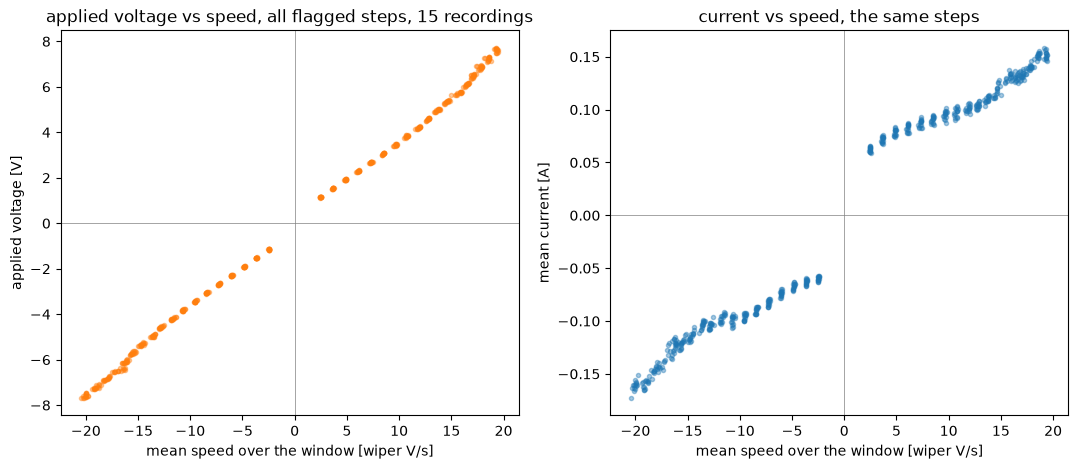

,speed_Vps,valid_frac,rail_V,idle_V,on_V,current_A,applied_V
duty_pct,,,,,,,
14.999847,2.467,1.000,7.716,0.078,7.633,0.061,1.145
19.998779,3.640,1.000,7.716,0.080,7.627,0.070,1.525
24.997711,4.841,1.000,7.714,0.085,7.622,0.077,1.905
29.999695,6.036,1.000,7.716,0.090,7.619,0.082,2.286
34.998627,7.255,1.000,7.716,0.092,7.617,0.085,2.666
39.997559,8.425,1.000,7.716,0.095,7.614,0.090,3.046
44.999542,9.652,1.000,7.716,0.100,7.611,0.095,3.425
49.998474,10.617,1.000,7.719,0.102,7.611,0.095,3.805
54.997406,11.696,1.000,7.721,0.105,7.607,0.101,4.183


In [6]:
TAIL = 0.6                  # fraction of each step used, the last 60% as in notebook 00

def step_window(seg, frac=TAIL):
    return seg.iloc[int(len(seg) * (1 - frac)):]

def step_speed(seg):
    t = (seg["tick"] - seg["tick"].iloc[0]) / TICK_HZ
    return np.polyfit(t, seg["pos"] * board.v_adc_per_count, 1)[0]

def drive_steps(df, frac=TAIL):
    vb_a, vb_b, bias = df["vb"].iloc[0], df["vb_b"].iloc[0], df["bias"].iloc[0]
    out = []
    for seg_id, seg in df.groupby("seg"):
        d = seg["duty_pct"].iloc[0]
        if seg_id == 0 or d == 0:
            continue
        sgn = int(np.sign(d))
        drv, idle, vb_d, vb_i = ("vmotor_a", "vmotor_b", vb_a, vb_b) if d > 0 else ("vmotor_b", "vmotor_a", vb_b, vb_a)
        w = step_window(seg, frac)
        v = w[w["window_valid"] == 1]
        row = {"duty_pct": d, "speed_Vps": step_speed(w), "valid_frac": seg["window_valid"].mean()}
        if len(v) >= 100:
            row.update({
                "rail_V": term_V(v[drv].quantile(0.9), vb_d),
                "idle_V": term_V(v[idle].median(), vb_i),
                "on_V": sgn * diff_V(v["vmotor_a"], v["vmotor_b"], vb_a, vb_b).mean(),
                "current_A": sgn * (v["current_raw"].mean() - bias) * board.a_per_count,
            })
        out.append(row)
    s = pd.DataFrame(out)
    s["applied_V"] = s["duty_pct"] / 100.0 * s["on_V"]
    return s

steps_a = {name: drive_steps(df).dropna(subset=["current_A"])
           for name, (df, _) in slow.items()}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, s in steps_a.items():
    axes[0].plot(s["speed_Vps"], s["applied_V"], "o", ms=3, alpha=0.4, color="tab:orange")
    axes[1].plot(s["speed_Vps"], s["current_A"], "o", ms=3, alpha=0.4, color="tab:blue")
axes[0].set_xlabel("mean speed over the window [wiper V/s]")
axes[0].set_ylabel("applied voltage [V]")
axes[0].set_title(f"applied voltage vs speed, all flagged steps, {len(steps_a)} recordings")
axes[1].set_xlabel("mean speed over the window [wiper V/s]")
axes[1].set_ylabel("mean current [A]")
axes[1].set_title("current vs speed, the same steps")
for ax in axes:
    ax.axhline(0, color="grey", lw=0.5)
    ax.axvline(0, color="grey", lw=0.5)
plt.show()

steps_a["bridge/capture-1"].set_index("duty_pct").round(3)

The driven terminal's 90th percentile averages 7.72 V at the 15% step and
7.76 V at 100%, so on 2S the rail **rises** slightly with duty where the
USB rail fell (individual steps span 7.56 to 7.88 V). The idle terminal
reads 0.03 to 0.15 V, rising with current. The 15% step already runs at 2.5 wiper V/s, well clear of the
motion threshold, so every flagged step of this dataset carries a real
speed.

The right panel is still the problem of route A in one picture. Current
and speed rise together across the grid, so the two regressors of the
joint fit are nearly proportional and the fit can trade $R$ against $K_e$
with little change in residual. Section 5.3 quantifies this and section
5.4 breaks the tie with an independent $R$.

### 5.2 Joint fit

Per recording, $\bar v = R\,\bar i + K_e\,\bar\omega$ is fitted by least
squares over all flagged steps of both directions with no intercept. The
signs are consistent by construction, since reverse steps carry negative
voltage, negative current and negative speed.

In [7]:
def fit_route_a(s):
    A = np.column_stack([s["current_A"], s["speed_Vps"]])
    x, _, _, sv = np.linalg.lstsq(A, s["applied_V"], rcond=None)
    resid = s["applied_V"] - A @ x
    return {"R_ohm": x[0], "Ke_V_per_Vps": x[1],
            "rms_resid_V": np.sqrt(np.mean(resid ** 2)),
            "corr_i_w": np.corrcoef(s["current_A"], s["speed_Vps"])[0, 1],
            "condition": sv[0] / sv[1], "steps": len(s)}

fits_a = pd.DataFrame([{"recording": n, **fit_route_a(s)} for n, s in steps_a.items()])
fits_a.set_index("recording").round(4)

,R_ohm,Ke_V_per_Vps,rms_resid_V,corr_i_w,condition,steps
recording,,,,,,
grid/capture-1,1.1993,0.3635,0.1720,0.9834,624.3617,36
grid/capture-2,1.4720,0.3612,0.1684,0.9853,665.0713,36
grid/capture-3,1.1473,0.3650,0.1656,0.9844,644.8127,36
grid/capture-4,1.3689,0.3627,0.1645,0.9831,620.9241,36
grid/capture-5,0.9217,0.3674,0.1918,0.9840,644.9974,36
grid/capture-6,0.5561,0.3714,0.1954,0.9832,643.7624,36
grid/capture-7,0.9497,0.3654,0.1763,0.9861,725.0781,36
grid/capture-8,1.4267,0.3619,0.1633,0.9833,641.5415,36
grid/capture-9,1.2385,0.3646,0.1688,0.9834,647.8851,36


In [8]:
summary_a = fits_a[["R_ohm", "Ke_V_per_Vps"]].agg(["mean", "std", "min", "max"]).T
summary_a["spread_pct"] = summary_a["std"] / summary_a["mean"].abs() * 100
summary_a.round(4)

,mean,std,min,max,spread_pct
R_ohm,1.3111,0.3737,0.5561,1.8881,28.5066
Ke_V_per_Vps,0.3630,0.0040,0.3560,0.3714,1.1005


### 5.3 Collinearity

The correlation between current and speed across the steps of a recording
is above 0.98 and the condition number of the design matrix is in the
hundreds. The joint fit therefore pins one combination of $R$ and $K_e$
and leaves the split between them weak. To make this concrete, for one
recording $K_e$ is stepped through a grid, $R$ is refitted at each value,
and the residual is tabulated.

In [9]:
def ke_at_fixed_r(s, r):
    return np.sum(s["speed_Vps"] * (s["applied_V"] - r * s["current_A"])) / np.sum(s["speed_Vps"] ** 2)

s = steps_a["bridge/capture-1"]
rows = []
for ke in np.arange(0.20, 0.50, 0.025):
    r = np.sum(s["current_A"] * (s["applied_V"] - ke * s["speed_Vps"])) / np.sum(s["current_A"] ** 2)
    resid = s["applied_V"] - r * s["current_A"] - ke * s["speed_Vps"]
    rows.append({"Ke_fixed": round(ke, 3), "R_refit_ohm": r,
                 "rms_resid_V": np.sqrt(np.mean(resid ** 2))})
pd.DataFrame(rows).set_index("Ke_fixed").round(4)

,R_refit_ohm,rms_resid_V
Ke_fixed,,
0.200,20.0618,0.3799
0.225,17.1806,0.3306
0.250,14.2993,0.2832
0.275,11.4181,0.2388
0.300,8.5368,0.1996
0.325,5.6556,0.1691
0.350,2.7743,0.1526
0.375,-0.1069,0.1547
0.400,-2.9882,0.1747


Findings:

- The free joint fit lands at $K_e$ = 0.363 V per wiper V/s and $R$ = 1.31
  Ohm, and that $R$ is a third of the winding resistance the full-duty
  steps show directly (section 5.4). The free fit is not a measurement of
  either constant; it is the best two-term line through steps whose current
  and speed rise together. On the USB run the same fit put $R$ three times
  **too high** instead, which is what a weakly determined split looks like:
  the sign of the error is set by the speed-per-ampere of the supply, not
  by the motor.
- The residual valley is shallow but one-sided. Moving $K_e$ from 0.30 to
  0.40 swings $R$ from 8.5 Ohm to -3.0 Ohm while the rms residual only runs
  from 0.20 V down to 0.15 V and back up to 0.17 V. Something in the steps
  is not in the two-term model, and section 5.5 shows a constant voltage
  term absorbs most of it.
- What the grid pins on its own is the combination $R + \kappa\,K_e$, with
  $\kappa$ the speed per ampere the fit sees across the flagged steps. On
  this supply $\kappa$ is about 119 wiper V/s per A, against 57 on USB and
  35 on the retired battery run, because 2S drives the same mechanism
  faster for the same current.

### 5.4 An independent anchor for R

The full-duty steps offer $R$ on its own. When the bridge switches on, the
current rises to its stall value within a few hundred microseconds, the
inductive term dies with it, and the mechanism has not yet gathered speed.
Over the window from 0.6 ms to 2 ms after the bridge switches on, the ratio
of the mean terminal difference to the mean crest-scan current is $R$ plus
whatever back-EMF the mechanism carries into the window, divided by the
current.

That residual back-EMF is the caveat. The positioning move that precedes
each step runs toward the far end of travel at the seek duty and ends at
the step edge, so the mechanism enters the step moving backward. The first
sample of the segment, before the bridge switches on, carries no current
and reads the terminal difference of the free winding, a backward EMF. On
2S the seek runs well above the motion threshold, so that entry EMF is
larger than it was on USB and the caveat is bigger, not smaller. The pot's
slope over the first 2 ms is tabulated too, but at these entry speeds it is
inside the pot's noise. The figure averages the first 10 ms of all 30
full-duty steps, with the anchor window shaded.

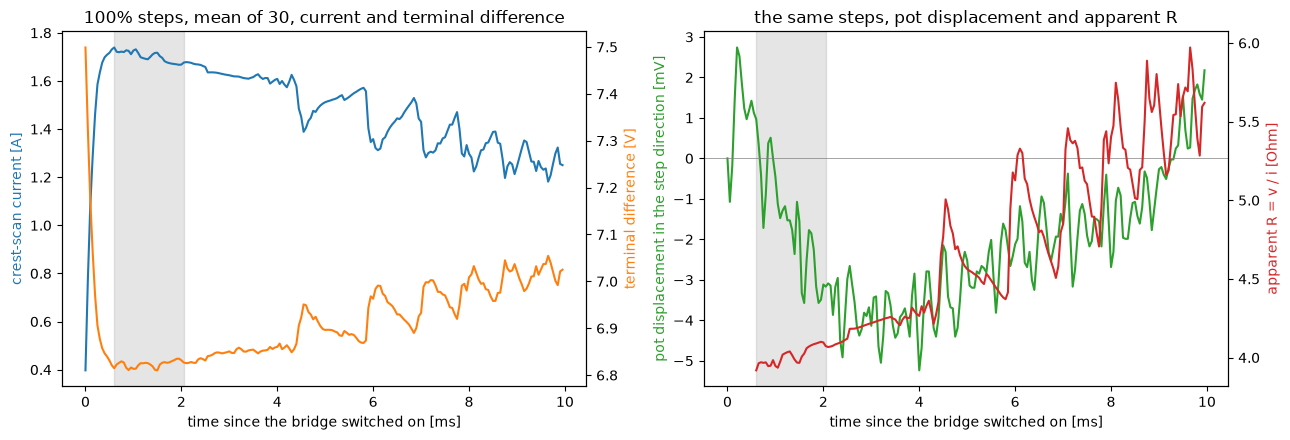

bridge_on_sample         e_edge_V         i_edge_A          \
                      mean     std     mean     std     mean     std   
direction                                                              
-1                  2.1333  0.3519  -0.6978  0.0402   0.0044  0.0013   
 1                  2.2667  0.4577  -0.7457  0.1317   0.0047  0.0010   

          i_window_A         v_window_V         R_window_ohm          
                mean     std       mean     std         mean     std  
direction                                                             
-1            1.6917  0.0318     6.7793  0.0679       4.0082  0.0604  
 1            1.7121  0.0334     6.8669  0.0687       4.0118  0.0660

In [10]:
ANCHOR_WINDOW = (12, 41)                 # samples after the bridge switches on, 0.6 ms to 2 ms
LATER_WINDOWS = {"R_0.6_1ms": (12, 21), "R_1_2ms": (21, 41), "R_2_3ms": (41, 61), "R_3_4ms": (61, 81)}
TRACE_SAMPLES = 200                      # 10 ms of the step start kept for the figure
BRIDGE_ON_A = 0.1                        # current that marks the first sample with the bridge on

def full_duty_steps(df):
    vb_a, vb_b, bias = df["vb"].iloc[0], df["vb_b"].iloc[0], df["bias"].iloc[0]
    for seg_id, seg in df.groupby("seg"):
        d = seg["duty_pct"].iloc[0]
        if seg_id == 0 or abs(d) < 99.9:
            continue
        sgn = int(np.sign(d))
        v = sgn * diff_V(seg["vmotor_a"].to_numpy(), seg["vmotor_b"].to_numpy(), vb_a, vb_b)
        i = (seg["current_raw"].to_numpy() - bias) * board.a_per_count
        pos = sgn * seg["pos"].to_numpy() * board.v_adc_per_count
        on = int(np.flatnonzero(i > BRIDGE_ON_A)[0])
        yield sgn, on, v, i, pos

def window_ratio(v, i, on, lo, hi):
    return v[on + lo:on + hi].mean() / i[on + lo:on + hi].mean()

rows, traces = [], []
lo, hi = ANCHOR_WINDOW
t2 = np.arange(41) / TICK_HZ
for name, (df, _) in slow.items():
    for sgn, on, v, i, pos in full_duty_steps(df):
        row = {"recording": name, "direction": sgn, "bridge_on_sample": on,
               "e_edge_V": v[0], "i_edge_A": i[0],
               "pot_speed_2ms_Vps": np.polyfit(t2, pos[on:on + 41], 1)[0],
               "v_window_V": v[on + lo:on + hi].mean(),
               "i_window_A": i[on + lo:on + hi].mean(),
               "R_window_ohm": window_ratio(v, i, on, lo, hi)}
        row.update({k: window_ratio(v, i, on, a, b) for k, (a, b) in LATER_WINDOWS.items()})
        rows.append(row)
        traces.append(np.column_stack([i[on:on + TRACE_SAMPLES], v[on:on + TRACE_SAMPLES],
                                       (pos[on:on + TRACE_SAMPLES] - pos[on]) * 1e3]))
anchor = pd.DataFrame(rows)
mean_trace = np.mean(traces, axis=0)
tm = np.arange(TRACE_SAMPLES) / TICK_HZ * 1e3

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
ax.plot(tm, mean_trace[:, 0], color="tab:blue")
ax.set_ylabel("crest-scan current [A]", color="tab:blue")
ax2 = ax.twinx()
ax2.plot(tm, mean_trace[:, 1], color="tab:orange")
ax2.set_ylabel("terminal difference [V]", color="tab:orange")
ax.axvspan(lo / TICK_HZ * 1e3, hi / TICK_HZ * 1e3, color="grey", alpha=0.2)
ax.set_xlabel("time since the bridge switched on [ms]")
ax.set_title(f"100% steps, mean of {len(anchor)}, current and terminal difference")
ax = axes[1]
ax.plot(tm, mean_trace[:, 2], color="tab:green")
ax.set_ylabel("pot displacement in the step direction [mV]", color="tab:green")
ax.axhline(0, color="grey", lw=0.5)
ax2 = ax.twinx()
ax2.plot(tm[lo:], mean_trace[lo:, 1] / mean_trace[lo:, 0], color="tab:red")
ax2.set_ylabel("apparent R = v / i [Ohm]", color="tab:red")
ax.axvspan(lo / TICK_HZ * 1e3, hi / TICK_HZ * 1e3, color="grey", alpha=0.2)
ax.set_xlabel("time since the bridge switched on [ms]")
ax.set_title("the same steps, pot displacement and apparent R")
fig.tight_layout()
plt.show()

anchor.groupby("direction")[["bridge_on_sample", "e_edge_V", "i_edge_A", "i_window_A",
                             "v_window_V", "R_window_ohm"]].agg(["mean", "std"]).round(4)

In [11]:
cols = ["R_window_ohm", *LATER_WINDOWS, "e_edge_V", "i_edge_A", "pot_speed_2ms_Vps", "i_window_A", "v_window_V"]
summary_r = anchor[cols].agg(["mean", "std", "min", "max"]).T
summary_r["spread_pct"] = summary_r["std"] / summary_r["mean"].abs() * 100
summary_r.round(4)

,mean,std,min,max,spread_pct
R_window_ohm,4.0100,0.0622,3.8151,4.0772,1.5506
R_0.6_1ms,3.9596,0.1055,3.6810,4.0510,2.6636
R_1_2ms,4.0343,0.0759,3.7536,4.1234,1.8806
R_2_3ms,4.1443,0.0980,3.6522,4.2068,2.3650
R_3_4ms,4.2517,0.0756,3.9387,4.3312,1.7774
e_edge_V,-0.7217,0.0987,-1.1466,-0.5918,13.6786
i_edge_A,0.0046,0.0012,0.0016,0.0066,25.3508
pot_speed_2ms_Vps,-2.4555,1.1325,-6.3583,-1.2548,46.1196
i_window_A,1.7019,0.0337,1.6524,1.7782,1.9787
v_window_V,6.8231,0.0805,6.6637,6.9585,1.1805


Findings:

- The window ratio repeats to 1.6% across the 30 steps, 4.01 Ohm with a
  spread of 0.06 Ohm. The stall current in the window is 1.70 A, against
  0.76 A on USB, and the terminal difference in the window is 6.82 V
  against a rail of 7.75 V, so 2S sags by about 12% under the inrush where
  USB sagged by 26%.
- Every step enters with a backward EMF at the edge, 0.59 to 1.15 V with
  at most 0.007 A of current. That is three times the USB figure, because
  the seek duty drives the mechanism much faster on this rail. The pot's
  2 ms slope is not usable here for the same reason as before: it reads the
  pot shifting by a few counts while the inrush flows, not motion, and its
  sign follows the step direction. So the edge EMF is the only reading of
  the entry motion, and no step is excluded.
- The apparent $R$ climbs through successive windows, 3.96 Ohm at 0.6 to
  1 ms, 4.03 at 1 to 2 ms, 4.14 at 2 to 3 ms and 4.25 at 3 to 4 ms, as the
  backward EMF dies and the forward EMF takes over.

The residual backward EMF adds to the terminal difference that the bridge
must overcome, so the window ratio reads low. Two bounds bracket the true
$R$ without a model of the reversal. The lower bound takes the residual
EMF in the window as zero, the window ratio as read. The upper bound holds
the edge EMF unchanged through the window and adds it back to the terminal
difference. The anchor is the midpoint of the bounds with the half-range
as its uncertainty.

In [12]:
r_low = anchor["R_window_ohm"]
r_high = (anchor["v_window_V"] - anchor["e_edge_V"]) / anchor["i_window_A"]
R_ANCHOR = (r_low.mean() + r_high.mean()) / 2
R_ANCHOR_HALF = (r_high.mean() - r_low.mean()) / 2
R_REG = servo.measured["r_winding_measured"]

pd.DataFrame([
    {"bound": "lower, residual EMF in the window taken as zero", "R_ohm": r_low.mean(), "std_over_steps": r_low.std()},
    {"bound": "upper, edge EMF held through the window", "R_ohm": r_high.mean(), "std_over_steps": r_high.std()},
    {"bound": "anchor, midpoint with half-range", "R_ohm": R_ANCHOR, "half_range": R_ANCHOR_HALF},
    {"bound": f"registry {R_REG.source} [{R_REG.lo:g}, {R_REG.hi:g}]", "R_ohm": R_REG.value},
]).set_index("bound").round(4).fillna("")

,R_ohm,std_over_steps,half_range
bound,,,
"lower, residual EMF in the window taken as zero",4.0100,0.0622,
"upper, edge EMF held through the window",4.4342,0.0877,
"anchor, midpoint with half-range",4.2221,,0.2121
"registry nb03, full duty onset anchor [4.3, 4.8]",4.5000,,


The anchor is $R$ = 4.22 Ohm with a bracket of 4.01 to 4.43. The registry
carries 4.5 [4.3, 4.8] from the USB run of this notebook, so the 2S
measurement lands 6% below it and the two brackets barely overlap. The 2S
figure is the better one: its inrush current is more than twice as large,
so the same absolute error in the residual EMF costs half as much in the
ratio, and its stall window sags 12% rather than 26%. The registry entry
is due an update, and section 12 lists it.

The bare-can figure in the registry, 4.2 Ohm from the encoder rig, agrees
with this one to 0.5%. That is a coincidence worth naming rather than
leaning on: the bare can has no gearbox load and this measurement has a
residual EMF it can only bracket, and the two errors happen to land in the
same place.

### 5.5 Route A with R anchored

With $R$ fixed at the anchor, $K_e$ alone is refitted per recording. The
same is done at the two bounds, so the table carries both the recording
spread and the shift that the anchor's uncertainty induces.

In [13]:
R_GRID = {"Ke_at_R_lower": R_ANCHOR - R_ANCHOR_HALF, "Ke_at_R_anchor": R_ANCHOR, "Ke_at_R_upper": R_ANCHOR + R_ANCHOR_HALF}
ke_anchor = pd.DataFrame({k: pd.Series({n: ke_at_fixed_r(s, r) for n, s in steps_a.items()})
                          for k, r in R_GRID.items()})
KE_A = ke_anchor["Ke_at_R_anchor"].mean()
KE_A_STD = ke_anchor["Ke_at_R_anchor"].std()
KE_A_SHIFT = (ke_anchor["Ke_at_R_lower"].mean() - ke_anchor["Ke_at_R_upper"].mean()) / 2
KE_A_SPREAD = np.hypot(KE_A_STD, KE_A_SHIFT)

summary = ke_anchor.agg(["mean", "std", "min", "max"])
summary.loc["R_ohm"] = list(R_GRID.values())
summary.loc["spread_pct"] = summary.loc["std"] / summary.loc["mean"] * 100
summary.round(4)

,Ke_at_R_lower,Ke_at_R_anchor,Ke_at_R_upper
mean,0.3402,0.3385,0.3367
std,0.0011,0.0011,0.0011
min,0.3382,0.3364,0.3346
max,0.3425,0.3408,0.3390
R_ohm,4.0100,4.2221,4.4342
spread_pct,0.3248,0.3298,0.3353


In [14]:
pd.DataFrame([{
    "Ke_route_A": KE_A,
    "recording_std": KE_A_STD,
    "shift_from_R_bounds": KE_A_SHIFT,
    "combined_spread": KE_A_SPREAD,
    "combined_spread_pct": KE_A_SPREAD / KE_A * 100,
    "recordings": len(ke_anchor),
}]).round(4)

,Ke_route_A,recording_std,shift_from_R_bounds,combined_spread,combined_spread_pct,recordings
0,0.3385,0.0011,0.0018,0.0021,0.6222,15


The result depends on the window, and that needs to be on the table before
it is compared with anything. The next cell repeats the anchored fit with
the means taken over the whole step, the last 60% (the result above) and
the last 40%. For each window it also fits the anchored equation with a
free constant voltage term, $\bar v - R\,\bar i = K_e\,\bar\omega + V_0$
with $V_0$ signed by direction, pooled over all recordings, as a check on
whether the two-term model is missing something that a constant would
absorb.

In [15]:
def anchored_with_intercept(steps):
    allr = pd.concat(steps.values())
    A = np.column_stack([allr["speed_Vps"], np.sign(allr["duty_pct"])])
    ke, v0 = np.linalg.lstsq(A, allr["applied_V"] - R_ANCHOR * allr["current_A"], rcond=None)[0]
    return ke, v0

rows = []
for label, frac in [("whole step", 1.0), ("last 60% (adopted)", 0.6), ("last 40%", 0.4)]:
    st = {n: drive_steps(df, frac).dropna(subset=["current_A"]) for n, (df, _) in slow.items()}
    kes = pd.Series({n: ke_at_fixed_r(s, R_ANCHOR) for n, s in st.items()})
    ke_i, v0 = anchored_with_intercept(st)
    full = pd.concat(st.values())
    full = full[full["duty_pct"].abs() > 99]
    rows.append({"window": label, "Ke_at_R_anchor": kes.mean(), "recording_std": kes.std(),
                 "Ke_with_intercept": ke_i, "V0_V": v0,
                 "current_at_100pct_A": full["current_A"].abs().mean(),
                 "applied_at_100pct_V": full["applied_V"].abs().mean()})
windows = pd.DataFrame(rows).set_index("window")
windows.round(4)

,Ke_at_R_anchor,recording_std,Ke_with_intercept,V0_V,current_at_100pct_A,applied_at_100pct_V
window,,,,,,
whole step,0.3108,0.0011,0.3172,-0.0838,0.4046,7.4654
last 60% (adopted),0.3385,0.0011,0.3524,-0.1964,0.1563,7.6010
last 40%,0.3367,0.0012,0.3514,-0.2093,0.1332,7.6159


Findings:

- With $R$ fixed, $K_e$ repeats to 0.33% across the 15 recordings at every
  value of $R$ in the bracket, and the anchor's bracket moves it by 0.0018
  either way, 0.5%. Route A with the adopted window gives $K_e$ = 0.3385 V
  per wiper V/s with a combined spread of 0.6%. That is a factor of three
  tighter than the USB run's 2.0%, and the reason is the supply: a flat
  rail leaves the recording-to-recording scatter nowhere to come from.
- Between windows the result moves by 9%: 0.311 with whole-step means
  against 0.3385 with the last 60% and 0.3367 with the last 40%. The
  difference is the current. The whole-step mean current at 100% is 0.40 A
  and the last-60% mean is 0.16 A, because the inrush decays over tens of
  milliseconds and a whole-step mean is not the current of the tail whose
  speed it is paired with. The last 40% and the last 60% agree to 0.5%,
  which is what a settled window looks like.
- The free constant term is -0.20 V in the adopted window, and with it the
  anchored $K_e$ rises to 0.352. Note the **sign**: on USB the same fit
  wanted +0.21 V and pulled $K_e$ down. A brush drop or a dead-time loss is
  a loss, so it can only take voltage away from the winding, which is the
  USB sign. A negative $V_0$ on 2S cannot be a loss term, and the most
  likely reading is that the true relation curves over the eightfold speed
  range this grid now covers while a straight line through it does not. The
  notebook reports route A without the term and carries it in section 12.

## 6. The fast-decay crest sample, a rejected candidate

Under fast decay the crest scan falls in the OFF portion of the period. If
the winding current has died by then, the sample should read the
open-circuit back-EMF while the step's speed is known, which would give a
direct channel inside a drive step. Notebook 01, section 5.3, examined this
reading in the same kind of recordings and found it on the terminal driven
low, whereas the coast segments put the back-EMF on the terminal driven
high.

The test here is the simplest one. For the low steps of the fast-decay
grid, the reading of the terminal driven low, in bias-corrected volts, is
plotted against the step's speed and against the drive current (the
trough-scan shunt, which sits in the ON portion under fast decay). The
table adds the terminal driven high and the rest-relative difference of the
two, signed so that a back-EMF in the drive direction would read positive.

The **slow-decay** crest terminal is worth naming in the same breath, since
it is the other thing a reader might mistake for a back-EMF channel. Under
slow decay the crest scan lands inside the ON portion, so the driven
terminal reads the rail: section 5.1's table shows it flat at 7.66 to
7.60 V of terminal difference from the 15% step to the 100% step while the
speed runs from 2.5 to 19.7 wiper V/s. A reading that does not move while
speed changes by a factor of eight is not a back-EMF, it is the supply.

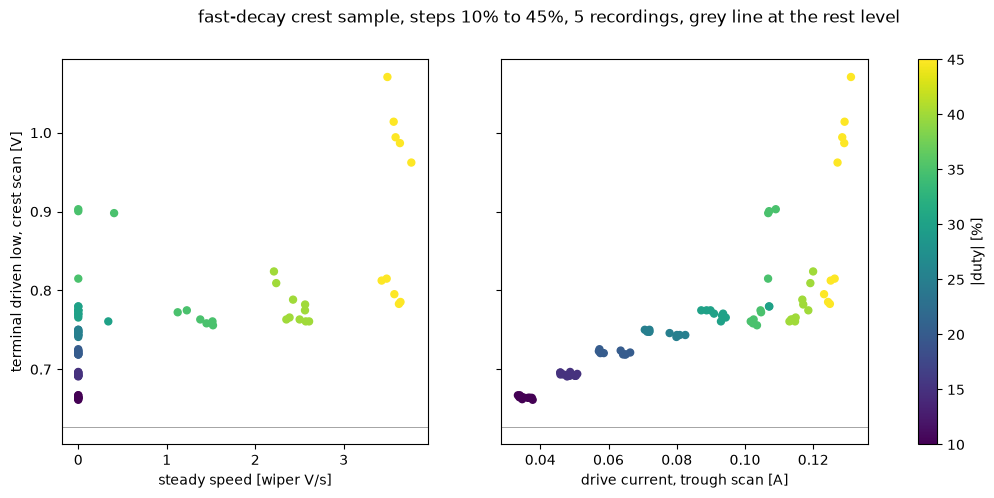

,steps,speed_mean_Vps,speed_max_Vps,reading_mean_V,reading_min_V,reading_max_V,high_terminal_mean_V,difference_mean_V,drive_current_A,corr_reading_speed_within_duty
duty_mag,,,,,,,,,,
10,10,0.000,0.000,0.664,0.661,0.667,0.603,-0.061,0.036,NaN
15,10,0.000,0.000,0.694,0.691,0.697,0.554,-0.140,0.048,NaN
20,10,0.000,0.000,0.721,0.719,0.725,0.466,-0.256,0.061,NaN
25,10,0.000,0.000,0.746,0.741,0.750,0.314,-0.433,0.076,NaN
30,10,0.034,0.339,0.772,0.761,0.780,0.072,-0.699,0.095,-0.653
35,10,0.862,1.522,0.810,0.756,0.903,-0.055,-0.866,0.105,-0.886
40,10,2.442,2.609,0.779,0.761,0.824,-0.036,-0.816,0.116,-0.740
45,10,3.580,3.764,0.902,0.783,1.071,-0.301,-1.203,0.127,0.105


In [16]:
FAST_BAND = (10, 45)         # duty magnitudes examined, the range that spans the motion onset

def fast_steps(df):
    vb_a, vb_b, bias = df["vb"].iloc[0], df["vb_b"].iloc[0], df["bias"].iloc[0]
    out = []
    for seg_id, seg in df.groupby("seg"):
        d = seg["duty_pct"].iloc[0]
        if seg_id == 0 or d == 0:
            continue
        high, low, vb_h, vb_l = ("vmotor_a", "vmotor_b", vb_a, vb_b) if d > 0 else ("vmotor_b", "vmotor_a", vb_b, vb_a)
        out.append({
            "duty_pct": d,
            "duty_mag": round(abs(d)),
            "speed_Vps": abs(step_speed(step_window(seg))),
            "reading_V": term_V(seg[low].median(), vb_l),
            "high_terminal_V": term_V(seg[high].median(), vb_h),
            "difference_V": np.sign(d) * np.median(diff_V(seg["vmotor_a"], seg["vmotor_b"], vb_a, vb_b)),
            "drive_current_A": (seg["current_trough"].mean() - bias) * board.a_per_count,
        })
    return pd.DataFrame(out)

steps_b = pd.concat([fast_steps(df).assign(recording=n) for n, (df, _) in fast.items()],
                    ignore_index=True)
sel = steps_b[steps_b["duty_mag"].between(*FAST_BAND)]
VB_REST_V = board.term_v(np.mean([df["vb"].iloc[0] for df, _ in fast.values()]),
                         np.mean([df["vb"].iloc[0] for df, _ in fast.values()]))  # a floating terminal at rest

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, x, xlabel in [(axes[0], "speed_Vps", "steady speed [wiper V/s]"),
                      (axes[1], "drive_current_A", "drive current, trough scan [A]")]:
    sc = ax.scatter(sel[x], sel["reading_V"], c=sel["duty_mag"], cmap="viridis", s=25)
    ax.axhline(VB_REST_V, color="grey", lw=0.5)
    ax.set_xlabel(xlabel)
axes[0].set_ylabel("terminal driven low, crest scan [V]")
fig.colorbar(sc, ax=axes, label="|duty| [%]")
fig.suptitle(f"fast-decay crest sample, steps {FAST_BAND[0]}% to {FAST_BAND[1]}%, "
             f"{len(fast)} recordings, grey line at the rest level")
plt.show()

by_duty = sel.groupby("duty_mag").agg(
    steps=("speed_Vps", "size"),
    speed_mean_Vps=("speed_Vps", "mean"),
    speed_max_Vps=("speed_Vps", "max"),
    reading_mean_V=("reading_V", "mean"),
    reading_min_V=("reading_V", "min"),
    reading_max_V=("reading_V", "max"),
    high_terminal_mean_V=("high_terminal_V", "mean"),
    difference_mean_V=("difference_V", "mean"),
    drive_current_A=("drive_current_A", "mean"),
)
by_duty["corr_reading_speed_within_duty"] = sel.groupby("duty_mag").apply(
    lambda g: np.corrcoef(g["speed_Vps"], g["reading_V"])[0, 1] if g["speed_Vps"].std() > 0.01 else np.nan,
    include_groups=False)
by_duty.round(3)

Findings:

- From 10% to 25% the servo does not move at all under fast decay (speed
  reads 0.000 wiper V/s in all ten recordings at every one of those rungs)
  while the reading climbs from 0.66 V to 0.75 V with duty, 0.04 to 0.13 V
  above the 0.62 V level of a floating terminal at rest. A back-EMF is zero
  at zero speed, so this is not one. At 30% one recording of ten just
  breaks away and the mean speed is 0.03 wiper V/s while the reading has
  climbed on to 0.77 V.
- Motion starts in earnest at 35%, and the reading keeps climbing with duty
  rather than with speed: 0.81 V at 35% and 0.90 V at 45% while the speed
  goes from 0.86 to 3.6 wiper V/s. Within a duty it is *negatively*
  correlated with speed, -0.65 to -0.89 at the rungs where the recordings
  differ.
- The terminal driven high falls with duty, from 0.60 V at 10% to -0.30 V
  at 45%, so the rest-relative difference is **opposite** to the drive
  direction and grows with the drive current, from -0.06 V to -1.20 V.
- Against the drive current the reading is a single rising curve across all
  duties. Against speed it is a ladder of duty levels.

The reading tracks the winding current and has the wrong sign for a
back-EMF in the drive direction. It is not a back-EMF, and no $K_e$ is
taken from it. The 2S data reaches the same verdict as the USB data did, at
a rail two thirds higher and with the motion onset in a different place,
which is the useful part: the rejection is a property of the scan geometry,
not of the supply. In this geometry the direct back-EMF is available only
from the coast segments, where the winding floats for the whole segment and
no PWM edge precedes the sample.

## 7. Route C: coast-down against pot speed

### 7.1 Method

Within each coast segment the winding floats for 400 ms while the
mechanism spins down. Both terminals are readable, so the back-EMF is the
rest-relative terminal difference of section 2

$$e = V_a - V_b$$

which is positive during a forward coast and negative during a reverse one,
the same sign convention as the wiper speed. The samples of a coast segment
fall into three phases, and the histogram below separates them by the
corrected terminal sum $V_a + V_b$ (each terminal in absolute volts with
its own rest reading). It pools every coast sample of all 30 segments,
split by position in the segment.

- The first two samples of a segment still read the drive, one terminal at
  the rail and the other near ground, so the sum sits at the rail.
- The body-diode phase, while the winding current returns to the supply,
  puts one terminal a diode drop above the rail and the other a diode drop
  below ground. With drive currents around 0.1 A it lasts at most one
  sample, and the sum sits near the rail too.
- From then on the winding floats and the sum is the back-EMF plus twice
  the level of the negative terminal.

The gate is the corrected sum against half the rail. A sample is in the
drive or diode phase when $V_a + V_b$ exceeds half the rail, and only
samples from the third onward below that level are used. In a few segments
one further sample follows the diode phase with the polarity reversed, the
positive terminal at the diode level below ground and the other above it.
That sample fails the sign gate below.

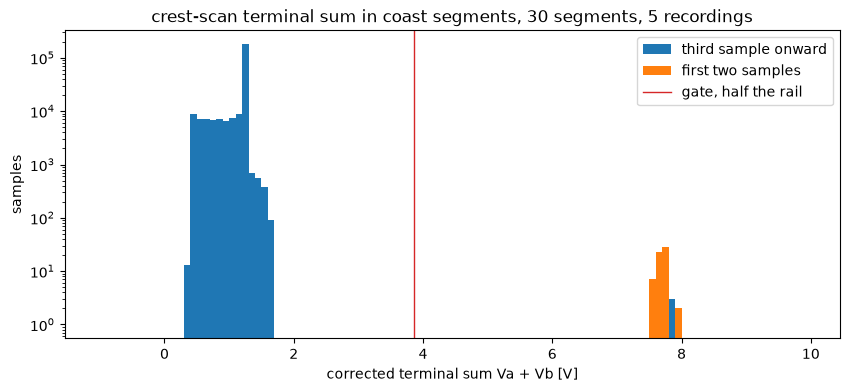

,samples,min_V,max_V,above_gate,rail_V
first two samples,60,7.569,7.954,60,7.736
third sample onward,239940,0.342,7.882,9,7.736


In [17]:
RAIL_V = pd.concat([s["rail_V"] for s in steps_a.values()]).mean()
SUM_GATE_V = RAIL_V / 2                  # corrected terminal sum above this is drive or diode phase

def terminals(seg, vb_a, vb_b):
    return term_V(seg["vmotor_a"].to_numpy(), vb_a), term_V(seg["vmotor_b"].to_numpy(), vb_b)

first_two, later = [], []
for df, meta in spin.values():
    vb_a, vb_b = df["vb"].iloc[0], df["vb_b"].iloc[0]
    for _, _, seg in coast_segments(df, meta):
        va, vb_ = terminals(seg, vb_a, vb_b)
        total = va + vb_
        first_two.append(total[:2])
        later.append(total[2:])
first_two, later = np.concatenate(first_two), np.concatenate(later)

fig, ax = plt.subplots(figsize=(10, 4))
bins = np.arange(-1, 10, 0.1)
ax.hist(later, bins=bins, log=True, color="tab:blue", label="third sample onward")
ax.hist(first_two, bins=bins, log=True, color="tab:orange", label="first two samples")
ax.axvline(SUM_GATE_V, color="tab:red", lw=1, label="gate, half the rail")
ax.set_xlabel("corrected terminal sum Va + Vb [V]")
ax.set_ylabel("samples")
ax.set_title(f"crest-scan terminal sum in coast segments, {len(spin) * 6} segments, {len(spin)} recordings")
ax.legend()
plt.show()

pd.DataFrame({
    "samples": [len(first_two), len(later)],
    "min_V": [first_two.min(), later.min()],
    "max_V": [first_two.max(), later.max()],
    "above_gate": [(first_two > SUM_GATE_V).sum(), (later > SUM_GATE_V).sum()],
    "rail_V": [RAIL_V, RAIL_V],
}, index=["first two samples", "third sample onward"]).round(3)

The two populations do not touch. The first two samples of every segment
read the drive or the diode phase and the gate sits in the empty band
between them and the floating population.

### 7.2 Per-sample quantities

Per sample from the third onward:

- **Back-EMF** $e$ as defined above, in volts at the terminals.
- **Speed** $\omega$ from a centred least-squares line over 41 samples
  (2 ms) of the wiper trace, evaluated at every sample.
- The used span runs from the first sample past the gate with $e$ of at
  least 0.02 V in the coast direction, which is the sign gate, to the
  first sample at which $|e|$ drops below 0.02 V, so the decay is covered
  and the span stops when the mechanism has come to rest. The regression
  additionally needs the centred window to fit inside the segment, which
  drops the first millisecond.

The wiper carries the noise. One ADC count over a 2 ms window is a speed
error of 0.4 V/s while the terminal difference is clean to a few
millivolts, so the fit minimizes speed residuals, $\omega = e / K_e +
\omega_0$, and reports $K_e$ as the inverse slope. A regression of $e$ on
the noisy speed would read low by the noise-to-signal ratio of the speed.
As an independent check that needs no derivative, the integral of $e$ over
the used span divided by the wiper travel over the same span gives $K_e$
again, since $\int e\,dt = K_e \int \omega\,dt = K_e\,\Delta p$.

On 2S every coast runs 60 ms or longer, so the `short` flag of the USB run
(coasts under 50 ms, whose 2 ms derivative had nothing to regress on) no
longer excludes anything. It is kept in the table so the criterion is
visible.

In [18]:
DERIV_WINDOW = 41          # samples, 2 ms centred fit
E_MIN_V = 0.02             # terminal volts
FIRST_SAMPLE = 2           # third sample of the segment onward
MIN_DECAY_MS = 50          # shorter decays are flagged short

def coast_trace(seg, vb_a, vb_b):
    d = int(seg["dir"].iloc[0])
    pos = seg["pos"].to_numpy() * board.v_adc_per_count
    w = savgol_filter(pos, DERIV_WINDOW, 1, deriv=1, delta=1.0 / TICK_HZ)
    va, vb_ = terminals(seg, vb_a, vb_b)
    e = diff_V(seg["vmotor_a"].to_numpy(), seg["vmotor_b"].to_numpy(), vb_a, vb_b)
    idx = np.arange(len(seg))
    ok = (idx >= FIRST_SAMPLE) & (va + vb_ < SUM_GATE_V) & (d * e >= E_MIN_V)
    start = np.flatnonzero(ok)[0]
    stop = np.flatnonzero(~ok & (idx > start))[0]      # mechanism at rest
    used = (idx >= start) & (idx < stop)
    # the centred derivative exists only where the window fits inside the segment
    fit = used & (idx >= DERIV_WINDOW // 2) & (idx < len(seg) - DERIV_WINDOW // 2)
    return idx / TICK_HZ, pos, w, e, used, fit, va, vb_

def coast_fits(df, meta):
    vb_a, vb_b = df["vb"].iloc[0], df["vb_b"].iloc[0]
    out = []
    for seg_id, level, seg in coast_segments(df, meta):
        d = int(seg["dir"].iloc[0])
        t, pos, w, e, used, fit, va, vb_ = coast_trace(seg, vb_a, vb_b)
        slope, icpt = np.polyfit(e[fit], w[fit], 1)
        span = np.flatnonzero(used)
        integral = np.trapezoid(e[used], t[used])
        travel = pos[span[-1]] - pos[span[0]]
        positive, negative = (va, vb_) if d > 0 else (vb_, va)
        decay_ms = (span[-1] - span[0]) / TICK_HZ * 1e3
        out.append({
            "seg": seg_id,
            "direction": d,
            "drive_pct": level,
            "samples_used": int(used.sum()),
            "samples_fit": int(fit.sum()),
            "decay_ms": decay_ms,
            "short": decay_ms < MIN_DECAY_MS,
            "e_start_V": e[span[0]],
            "negative_terminal_V": np.median(negative[span[0]:span[0] + 400]),
            "Ke_fit": 1.0 / slope,
            "w_intercept_Vps": icpt,
            "Ke_integral": integral / travel,
            "integral_Vs": integral,
            "travel_V": travel,
        })
    return pd.DataFrame(out)

coasts = pd.concat([coast_fits(df, meta).assign(recording=n) for n, (df, meta) in spin.items()],
                   ignore_index=True)
coasts[coasts["recording"] == "bridge/capture-1"].set_index("seg").drop(
    columns=["recording", "integral_Vs", "travel_V"]).round(4)

,direction,drive_pct,samples_used,samples_fit,decay_ms,short,e_start_V,negative_terminal_V,Ke_fit,w_intercept_Vps,Ke_integral
seg,,,,,,,,,,,
2,1,20.0,1402,1384,70.05,False,0.8088,-0.0999,0.2810,-0.2396,0.3324
6,1,30.0,2261,2243,113.00,False,1.3957,-0.4426,0.2623,-0.1295,0.2749
10,1,40.0,3043,3025,152.10,False,1.6891,-0.4623,0.3080,0.0885,0.3009
14,-1,20.0,1453,1437,72.60,False,-0.9419,-0.1092,0.3465,-0.4193,0.2774
18,-1,30.0,2298,2280,114.85,False,-1.1540,-0.4606,0.2570,0.0242,0.2554
22,-1,40.0,3139,3121,156.90,False,-1.5387,-0.4877,0.2761,0.1032,0.2836


### 7.3 One decay

The forward coast after the 40% step of the first recording. The left panel
shows both terminals in corrected volts and their difference, the middle
panel the back-EMF and the wiper speed on one time axis, and the right
panel the fit.

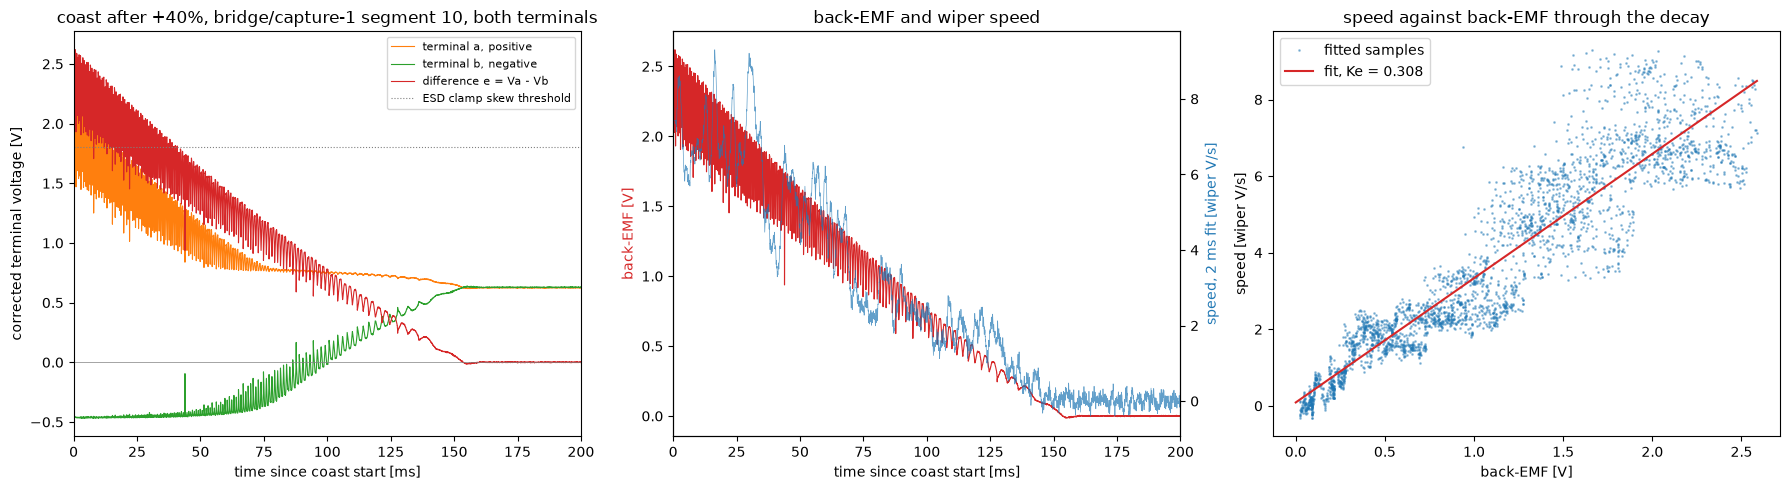

,samples_used,samples_fit,decay_ms,e_start_V,negative_terminal_V,Ke_fit,w_intercept_Vps,Ke_integral
2,3043,3025,152.1,1.6891,-0.4623,0.308,0.0885,0.3009


In [19]:
ESD_SKEW_V = board.measured["esd_clamp_skew_measured"].value   # above this the A-side clamp skews the split

df_s, meta_s = spin["bridge/capture-1"]
seg_id = int(coasts[(coasts["recording"] == "bridge/capture-1")
                    & (coasts["direction"] == 1) & (coasts["drive_pct"] == 40)]["seg"].iloc[0])
seg = df_s[df_s["seg"] == seg_id]
t, pos, w, e, used, fit, va, vb_ = coast_trace(seg, df_s["vb"].iloc[0], df_s["vb_b"].iloc[0])
row = coasts[(coasts["recording"] == "bridge/capture-1") & (coasts["seg"] == seg_id)].iloc[0]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ax = axes[0]
ax.plot(t[FIRST_SAMPLE:] * 1e3, va[FIRST_SAMPLE:], color="tab:orange", lw=0.8, label="terminal a, positive")
ax.plot(t[FIRST_SAMPLE:] * 1e3, vb_[FIRST_SAMPLE:], color="tab:green", lw=0.8, label="terminal b, negative")
ax.plot(t[FIRST_SAMPLE:] * 1e3, e[FIRST_SAMPLE:], color="tab:red", lw=0.8, label="difference e = Va - Vb")
ax.axhline(0, color="grey", lw=0.5)
ax.axhline(ESD_SKEW_V, color="grey", lw=0.8, ls=":", label="ESD clamp skew threshold")
ax.set_xlim(0, 200)
ax.set_xlabel("time since coast start [ms]")
ax.set_ylabel("corrected terminal voltage [V]")
ax.set_title(f"coast after +40%, bridge/capture-1 segment {seg_id}, both terminals")
ax.legend(fontsize=8)
ax = axes[1]
ax.plot(t[FIRST_SAMPLE:] * 1e3, e[FIRST_SAMPLE:], color="tab:red", lw=0.8)
ax.set_xlabel("time since coast start [ms]")
ax.set_ylabel("back-EMF [V]", color="tab:red")
ax2 = ax.twinx()
ax2.plot(t * 1e3, w, color="tab:blue", lw=0.5, alpha=0.7)
ax2.set_ylabel("speed, 2 ms fit [wiper V/s]", color="tab:blue")
ax.set_xlim(0, 200)
ax.set_title("back-EMF and wiper speed")
ax = axes[2]
ax.plot(e[fit], w[fit], ".", ms=2, alpha=0.4, label="fitted samples")
ee = np.linspace(0, e[fit].max(), 10)
ax.plot(ee, ee / row["Ke_fit"] + row["w_intercept_Vps"], color="tab:red",
        label=f"fit, Ke = {row['Ke_fit']:.3f}")
ax.set_xlabel("back-EMF [V]")
ax.set_ylabel("speed [wiper V/s]")
ax.set_title("speed against back-EMF through the decay")
ax.legend()
fig.tight_layout()
plt.show()

pd.DataFrame([row[["samples_used", "samples_fit", "decay_ms", "e_start_V", "negative_terminal_V",
                   "Ke_fit", "w_intercept_Vps", "Ke_integral"]]]).round(4)

The back-EMF starts at 2.0 V, twice the 1.0 V that the same step gave on
USB, and decays to zero over about 145 ms. The negative terminal sits at
-0.46 V while the back-EMF is near 2 V, the level at which the body diode
of the low-side switch conducts, and lifts toward the rest level as the
back-EMF falls, while the positive terminal carries the rest of the swing.
The single-terminal reading is therefore a fraction of $e$ that changes
through the decay, and the difference removes it.

Two features of this trace matter downstream.

- The **commutation ripple** is plainly visible on both terminals and on
  their difference, several hundred millivolts peak to peak at the start of
  the coast, and its frequency falls with the speed. Section 8 turns that
  ripple into the tachometer this notebook needs. Read against a
  single-sample back-EMF it is a large error, which is why section 8
  averages the back-EMF over a whole number of ripple periods rather than
  taking one sample.
- The dotted line marks the board's declared **ESD clamp skew threshold**,
  1.8 V. Above it the A-side clamp starts to take current and skews how the
  winding's EMF divides between the two taps. The 40% coasts start above
  it, the 30% and 20% coasts do not. That is a candidate for the direction
  gap of section 7.5, and section 12 says what would separate it.

### 7.4 All coast segments

Thirty coast segments, six per recording. The first table groups them by
direction and by the drive level that preceded the coast, which sets the
starting speed. The second pools each recording's six segments, with the
regression over all their used samples and the ratio of the summed
integrals to the summed travel, both taken in the coast direction.

In [20]:
long = coasts[~coasts["short"]]
grouped = coasts.groupby(["direction", "drive_pct"]).agg(
    segments=("seg", "size"),
    short=("short", "sum"),
    decay_ms=("decay_ms", "mean"),
    e_start_V=("e_start_V", lambda x: x.abs().mean()),
    negative_terminal_V=("negative_terminal_V", "mean"),
    Ke_fit_mean=("Ke_fit", "mean"),
    Ke_fit_std=("Ke_fit", "std"),
    Ke_integral_mean=("Ke_integral", "mean"),
    Ke_integral_std=("Ke_integral", "std"),
)
overall = pd.DataFrame({
    "segments": [len(long)],
    "short": [int(coasts["short"].sum())],
    "decay_ms": [long["decay_ms"].mean()],
    "e_start_V": [long["e_start_V"].abs().mean()],
    "negative_terminal_V": [long["negative_terminal_V"].mean()],
    "Ke_fit_mean": [long["Ke_fit"].mean()],
    "Ke_fit_std": [long["Ke_fit"].std()],
    "Ke_integral_mean": [long["Ke_integral"].mean()],
    "Ke_integral_std": [long["Ke_integral"].std()],
}, index=pd.MultiIndex.from_tuples([("all", "not short")], names=["direction", "drive_pct"]))
pd.concat([grouped, overall]).round(4)

segments  short  decay_ms  e_start_V  \
direction drive_pct                                         
-1        20.0              5      0     74.88     0.8596   
          30.0              5      0    120.46     1.2413   
          40.0              5      0    162.15     1.9672   
1         20.0              5      0     70.67     0.7126   
          30.0              5      0    107.97     1.3769   
          40.0              5      0    143.49     2.0018   
all       not short        30      0    113.27     1.3599   

                     negative_terminal_V  Ke_fit_mean  Ke_fit_std  \
direction drive_pct                                                 
-1        20.0                   -0.1154       0.3055      0.0283   
          30.0                   -0.4606       0.2555      0.0085   
          40.0                   -0.4877       0.2776      0.0015   
1         20.0                   -0.1139       0.3141      0.0336   
          30.0                   -0.4421       0.2628      0.0320   
          40.0                   -0.4623       0.3092      0.0034   
all       not short              -0.3470       0.2875      0.0313   

                     Ke_integral_mean  Ke_integral_std  
direction drive_pct                                     
-1        20.0                 0.2999           0.0127  
          30.0                 0.2672           0.0096  
          40.0                 0.2846           0.0012  
1         20.0                 0.3224           0.0246  
          30.0                 0.2797           0.0074  
          40.0                 0.3004           0.0008  
all       not short            0.2924           0.0212

In [21]:
rows = []
for name, (df, meta) in spin.items():
    vb_a, vb_b = df["vb"].iloc[0], df["vb_b"].iloc[0]
    es, ws = [], []
    for _, _, seg in coast_segments(df, meta):
        _, _, w, e, used, fit, _, _ = coast_trace(seg, vb_a, vb_b)
        es.append(e[fit])
        ws.append(w[fit])
    es, ws = np.concatenate(es), np.concatenate(ws)
    slope, icpt = np.polyfit(es, ws, 1)
    c = coasts[coasts["recording"] == name]
    rows.append({"recording": name, "samples": len(es),
                 "Ke_regression": 1.0 / slope, "w_intercept_Vps": icpt,
                 "Ke_integral": (c["direction"] * c["integral_Vs"]).sum() / (c["direction"] * c["travel_V"]).sum()})
pooled_c = pd.DataFrame(rows).set_index("recording")
summary_c = pooled_c[["Ke_regression", "Ke_integral"]].agg(["mean", "std", "min", "max"]).T
summary_c["spread_pct"] = summary_c["std"] / summary_c["mean"] * 100
pd.concat([pooled_c.round(4), summary_c.round(4)], axis=0).fillna("")

,samples,Ke_regression,w_intercept_Vps,Ke_integral,mean,std,min,max,spread_pct
bridge/capture-1,13490.0,0.2843,-0.1122,0.284,,,,,
bridge/capture-2,13493.0,0.2892,-0.0437,0.2893,,,,,
bridge/capture-3,13463.0,0.2888,-0.0986,0.2903,,,,,
bridge/capture-4,13629.0,0.2883,-0.0522,0.2891,,,,,
bridge/capture-5,13386.0,0.2851,-0.0981,0.2867,,,,,
Ke_regression,,,,,0.2871,0.0023,0.2843,0.2892,0.7879
Ke_integral,,,,,0.2879,0.0025,0.284,0.2903,0.8704


### 7.5 The terminal split

The two directions do not agree, and the terminal split of section 2 is the
first suspect, so the next table pools the integral ratio by direction under
three readings of the split. The adopted one is the rest-relative
difference, which is zero at rest by measurement (section 4.2). The second
is the difference of the two per-terminal absolute voltages. The third
ignores the split and takes the raw tap difference, as if both taps shared
one bias.

In [22]:
SPLIT_READINGS = {
    "rest-relative (adopted)": 0.0,
    "per-terminal absolute difference": 1.0,
    "raw tap difference, one shared bias": board.div_ratio,
}
rows = []
for label, k in SPLIT_READINGS.items():
    by_dir = {1: [0.0, 0.0], -1: [0.0, 0.0]}
    for name, (df, meta) in spin.items():
        vb_a, vb_b = df["vb"].iloc[0], df["vb_b"].iloc[0]
        offset = k * (vb_a - vb_b) * board.v_adc_per_count      # what this reading adds to e at rest
        for _, _, seg in coast_segments(df, meta):
            d = int(seg["dir"].iloc[0])
            t, pos, _, e, used, _, _, _ = coast_trace(seg, vb_a, vb_b)
            span = np.flatnonzero(used)
            by_dir[d][0] += d * np.trapezoid(e[used] + offset, t[used])
            by_dir[d][1] += d * (pos[span[-1]] - pos[span[0]])
    kf, kr = by_dir[1][0] / by_dir[1][1], by_dir[-1][0] / by_dir[-1][1]
    vb_a0, vb_b0 = spin["bridge/capture-1"][0]["vb"].iloc[0], spin["bridge/capture-1"][0]["vb_b"].iloc[0]
    rows.append({"reading of the split": label,
                 "e_at_rest_mV": k * (vb_a0 - vb_b0) * board.v_adc_per_count * 1e3,
                 "Ke_integral_forward": kf, "Ke_integral_reverse": kr,
                 "forward_minus_reverse_pct": (kf - kr) / ((kf + kr) / 2) * 100})
pd.DataFrame(rows).set_index("reading of the split").round(4)

,e_at_rest_mV,Ke_integral_forward,Ke_integral_reverse,forward_minus_reverse_pct
reading of the split,,,,
rest-relative (adopted),-0.0000,0.2959,0.2806,5.3225
per-terminal absolute difference,-3.2227,0.2949,0.2816,4.6109
"raw tap difference, one shared bias",-9.8633,0.2928,0.2837,3.1445


Findings:

- Pooled per recording, the integral ratio gives 0.288 and the regression
  0.289, each repeating to under 1% across the five recordings. That
  repeatability is the trap: route C is *precise* and, section 8 shows, not
  accurate.
- Per segment, the integral gives 0.292 with a 7% spread and the regression
  0.288 with an 11% spread. The spread is between the groups, not within
  them. The 20% coasts give 0.30 to 0.32, the 30% coasts 0.27 and the 40%
  coasts 0.28 to 0.30, so the estimate moves with the entry speed, which a
  constant $K_e$ would not do.
- The direction gap is 5% on the pooled integral with the adopted reading
  of the split, and the other two readings move it by only a fraction of a
  point, because the split is now 4 counts rather than 18. On the USB
  chain the same table moved the gap by 20 points. **The split is no longer
  a candidate explanation for anything here.** That is a real result of the
  bias-return rework, and it removes one of the USB run's open items.
- The negative terminal sits at -0.44 to -0.49 V through the 30% and 40%
  coasts, at the diode level, and at -0.11 V through the 20% coasts, whose
  back-EMF never gets far above it.

### 7.6 Coast against brake

The spin-down schedule pairs every coast with a brake from the same drive
level, which makes the control this notebook needs: the same mechanism at
the same speed, with the bridge shorted instead of open. If the terminal
difference read a back-EMF whenever the motor turns, brake would read it
too.

In [23]:
def brake_segments(df, meta):
    return zero_segments(df, meta, "brake")

CMP_SAMPLES = 20            # 1 ms past the gate, close enough to the entry speed to be matched

rows = []
for name, (df, meta) in spin.items():
    vb_a, vb_b, bias = df["vb"].iloc[0], df["vb_b"].iloc[0], df["bias"].iloc[0]
    for kind, gen in (("coast", coast_segments), ("brake", brake_segments)):
        for seg_id, level, seg in gen(df, meta):
            d = int(seg["dir"].iloc[0])
            e = d * diff_V(seg["vmotor_a"].to_numpy(), seg["vmotor_b"].to_numpy(), vb_a, vb_b)
            i = (seg["current_raw"].to_numpy() - bias) * board.a_per_count
            va, vb_ = terminals(seg, vb_a, vb_b)
            idx = np.arange(len(seg))
            # same gate as route C, so the drive tail cannot leak into either population
            w = np.flatnonzero((idx >= FIRST_SAMPLE) & (va + vb_ < SUM_GATE_V))[:CMP_SAMPLES]
            rows.append({"kind": kind, "drive_pct": level, "direction": d,
                         "terminal_difference_V": e[w].mean(), "shunt_A": i[w].mean(),
                         "terminal_sum_V": (va + vb_)[w].mean()})
brake = pd.DataFrame(rows)
display(brake.groupby(["drive_pct", "kind"])[["terminal_difference_V", "terminal_sum_V", "shunt_A"]]
        .agg(["mean", "std"]).round(4))

piv = brake.groupby(["drive_pct", "kind"])["terminal_difference_V"].mean().unstack("kind")
piv["brake_pct_of_coast"] = piv["brake"] / piv["coast"] * 100
piv.round(4)

terminal_difference_V         terminal_sum_V         shunt_A  \
                                 mean     std           mean     std    mean   
drive_pct kind                                                                 
20.0      brake                0.0460  0.0028        -0.0036  0.0036  0.0049   
          coast                1.0066  0.0103         0.5410  0.0086  0.0042   
30.0      brake                0.0740  0.0032        -0.0012  0.0029  0.0049   
          coast                1.6891  0.0133         0.7802  0.0183  0.0045   
40.0      brake                0.0988  0.0033         0.0050  0.0053  0.0066   
          coast                2.3412  0.0154         1.3966  0.0343  0.0045   

                         
                    std  
drive_pct kind           
20.0      brake  0.0011  
          coast  0.0007  
30.0      brake  0.0011  
          coast  0.0005  
40.0      brake  0.0020  
          coast  0.0006

kind,brake,coast,brake_pct_of_coast
drive_pct,,,
20.0,0.0460,1.0066,4.5748
30.0,0.0740,1.6891,4.3803
40.0,0.0988,2.3412,4.2192


Findings:

- At matched entry speed the coast terminals read 1.01, 1.69 and 2.34 V
  after the 20%, 30% and 40% steps. The brake terminals read 0.046, 0.074
  and 0.099 V, which is 4.2 to 4.6% of the coast reading at the same speed.
- The brake residual grows with speed, so it is not an offset. It is the
  drop across the two low-side switches carrying the circulating current,
  $i\,R_{ds}$, and the current is what makes it grow.
- The shunt cannot confirm that here. It reads 4 to 7 mA in both
  populations, which is its rest noise: under slow decay the circulating
  current runs through the winding and the two low-side switches and
  bypasses the shunt entirely. So this dataset shows the *shape* of the
  brake residual, not its resistance. Section 12 names the measurement that
  would.

**Back-EMF is readable only during a genuine coast.** In brake both
terminals sit at roughly ground and the winding is shorted, so the EMF
drives a circulating current instead of appearing across the taps, and what
is left on the terminals is a switch drop that happens to move with speed.
Every back-EMF number in this notebook comes from a coast segment, and
nothing downstream should read the terminal difference during brake as a
speed signal.

## 8. Route R: the motor's own tachometer

### 8.1 Method

Routes A and C both measure a terminal voltage against a **pot** speed.
The pot is on the output shaft, on the far side of 234.73:1 of gear train,
and section 8.2 shows what that costs. This route replaces the pot with a
speed the motor reports about itself.

A brushed can with a 3-segment commutator and two brushes switches the
winding six times per motor revolution, and each switch shows up as a
disturbance in the winding current. The drive current therefore carries a
line at six times the motor's rotation rate. Both halves of that statement
are counted rather than fitted: the gear ratio is
$(47 \cdot 38 \cdot 32 \cdot 23)/(10 \cdot 10 \cdot 8 \cdot 7) = 234.73$
from teeth on the donor's gears, and the ripple order is 6 per revolution
from the commutator's geometry, cross-checked against an optical tach on a
sibling can.

The spin-down schedule is exactly the pairing this needs: every coast is
preceded by an 80 ms drive segment at the same duty. So

- **Speed** comes from the drive segment. Welch on `current_raw` over the
  segment, then the strongest line in a search band, refined to the
  power-weighted centroid of that peak. Motor rev/s is the line over 6.
- **Back-EMF** comes from the coast segment that follows, averaged over a
  whole number of ripple periods starting at the first floating sample.
  Averaging over whole periods is what makes this repeat: the ripple on
  the terminals is several hundred millivolts peak to peak at these
  speeds, and the very first floating sample sits at the bridge edge
  before the tap has settled, so on its own it reads 20% low.

$K_e$ is the ratio, in millivolts per motor revolution per second. **No pot
reading enters it.**

Two details are worth stating because they are where a ripple tach usually
goes wrong.

- **The search band.** A bare argmax from DC locks onto a subharmonic or
  onto the 1250 Hz line the bus telemetry couples into the amplifier
  (notebook 07), and the answer then looks plausible and is wrong by an
  integer factor. The band here runs from 600 Hz, below the 20% rung's
  line, to 5200 Hz. That lower edge is well under the 1400 Hz that suits
  the faster grid rungs of notebook 07, so the identity of the line is
  checked directly rather than assumed: section 8.2 puts the ripple speed
  next to the pot speed measured over the same drive segment, and they
  agree to about 5%, which no subharmonic could do.
- **The known bias.** The drive ripple is an average over a segment in
  which the shaft is still accelerating, while the back-EMF is read at the
  end of that acceleration. So the speed reads slightly low and $K_e$
  slightly high. The table below reports the drift with the averaging
  window so the size of it is visible.

In [24]:
GEAR = servo.measured["gear_ratio_measured"]        # 234.73:1, counted teeth
RIPPLE_ORDER = servo.measured["ripple_order_measured"]   # 6 per motor rev, a parts count
SEARCH_BAND = (600.0, 5200.0)   # Hz; the 20% rung sits near 820 Hz, so 1400 would clip it
BEMF_PERIODS = 2.0              # the BEMF average spans this many whole ripple periods

def ripple_hz(current_raw, band=SEARCH_BAND):
    # Strongest line in the band, refined to the power-weighted centroid of its own peak.
    f, P = welch(detrend(np.asarray(current_raw, dtype=float)), fs=TICK_HZ,
                 nperseg=min(1024, len(current_raw)))
    m = (f > band[0]) & (f < band[1])
    peak = f[m][np.argmax(P[m])]
    c = (f > 0.85 * peak) & (f < 1.15 * peak)
    return float(np.sum(f[c] * P[c]) / np.sum(P[c])), peak

def coast_bemf(seg, vb_a, vb_b, f6, periods=BEMF_PERIODS):
    # Mean back-EMF over `periods` ripple periods from the first floating sample. A whole
    # period is what makes this repeat: the ripple is several hundred mV peak to peak at
    # these speeds, so a fraction of one lands wherever the commutator happens to be.
    d = int(seg["dir"].iloc[0])
    e = d * diff_V(seg["vmotor_a"].to_numpy(), seg["vmotor_b"].to_numpy(), vb_a, vb_b)
    va, vb_ = terminals(seg, vb_a, vb_b)
    idx = np.arange(len(seg))
    start = np.flatnonzero((idx >= FIRST_SAMPLE) & (va + vb_ < SUM_GATE_V))[0]
    n = max(1, int(round(periods * TICK_HZ / f6)))
    return e[start:start + n].mean(), start, n

def route_r(dataset, recs):
    rows = []
    for name, (df, meta) in recs.items():
        vb_a, vb_b = df["vb"].iloc[0], df["vb_b"].iloc[0]
        segs = dict(list(df.groupby("seg")))
        for seg_id, level, seg in coast_segments(df, meta):
            drive = segs[seg_id - 1]
            f6, raw_peak = ripple_hz(drive["current_raw"])
            e0, start, n = coast_bemf(seg, vb_a, vb_b, f6)
            rows.append({"recording": name, "seg": seg_id, "direction": int(seg["dir"].iloc[0]),
                         "drive_pct": level, "ripple_Hz": f6, "argmax_Hz": raw_peak,
                         "motor_rev_s": f6 / RIPPLE_ORDER.value,
                         "bemf_V": e0, "bemf_samples": n, "first_floating": start})
    t = pd.DataFrame(rows)
    t["Ke_mV_per_rev_s"] = t["bemf_V"] / t["motor_rev_s"] * 1e3
    return t

route_r_2s = route_r(ds, spin)
KE_R = route_r_2s["Ke_mV_per_rev_s"].mean()
KE_R_STD = route_r_2s["Ke_mV_per_rev_s"].std()

display(route_r_2s.groupby(["direction", "drive_pct"]).agg(
    segments=("seg", "size"),
    ripple_Hz=("ripple_Hz", "mean"),
    motor_rev_s=("motor_rev_s", "mean"),
    bemf_V=("bemf_V", "mean"),
    bemf_samples=("bemf_samples", "mean"),
    Ke_mean=("Ke_mV_per_rev_s", "mean"),
    Ke_std=("Ke_mV_per_rev_s", "std")).round(4))

pd.DataFrame([{"Ke_mV_per_motor_rev_s": KE_R, "std": KE_R_STD, "CV_pct": KE_R_STD / KE_R * 100,
               "segments": len(route_r_2s),
               "registry": servo.measured["ke_measured"].value,
               "vs_registry_pct": (KE_R / servo.measured["ke_measured"].value - 1) * 100}]).round(4)

segments  ripple_Hz  motor_rev_s  bemf_V  bemf_samples  \
direction drive_pct                                                           
-1        20.0              5   797.6491     132.9415  1.0064          50.0   
          30.0              5  1323.5768     220.5961  1.6735          30.0   
          40.0              5  1854.7007     309.1168  2.3328          21.4   
 1        20.0              5   801.7871     133.6312  1.0147          50.0   
          30.0              5  1333.0207     222.1701  1.6879          30.0   
          40.0              5  1850.6069     308.4345  2.3477          21.8   

                     Ke_mean  Ke_std  
direction drive_pct                   
-1        20.0        7.5704  0.0591  
          30.0        7.5865  0.0303  
          40.0        7.5472  0.1058  
 1        20.0        7.5931  0.0424  
          30.0        7.5977  0.0552  
          40.0        7.6124  0.1139

,Ke_mV_per_motor_rev_s,std,CV_pct,segments,registry,vs_registry_pct
0,7.5845,0.0711,0.9379,30,7.367,2.9528


In [25]:
# How much of the answer is the averaging window. The two errors pull opposite ways: less
# than a period lands on an arbitrary commutator phase and scatters, more than a couple of
# periods reaches into the decay and reads low.
rows = []
for periods in (0.04, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0):
    vals, spans = [], []
    for name, (df, meta) in spin.items():
        vb_a, vb_b = df["vb"].iloc[0], df["vb_b"].iloc[0]
        segs = dict(list(df.groupby("seg")))
        for seg_id, level, seg in coast_segments(df, meta):
            f6, _ = ripple_hz(segs[seg_id - 1]["current_raw"])
            e0, _, n = coast_bemf(seg, vb_a, vb_b, f6, periods=periods)
            vals.append(e0 / (f6 / RIPPLE_ORDER.value) * 1e3)
            spans.append(n)
    v = np.array(vals)
    rows.append({"ripple_periods": periods, "samples": np.mean(spans),
                 "span_ms": np.mean(spans) / TICK_HZ * 1e3,
                 "Ke_mV_per_rev_s": v.mean(), "std": v.std(ddof=1),
                 "CV_pct": v.std(ddof=1) / v.mean() * 100})
pd.DataFrame(rows).set_index("ripple_periods").round(4)

,samples,span_ms,Ke_mV_per_rev_s,std,CV_pct
ripple_periods,,,,,
0.04,1.0000,0.0500,6.0809,0.8862,14.5741
0.25,4.3333,0.2167,7.3326,0.4403,6.0051
0.50,8.3333,0.4167,7.5191,0.2873,3.8210
1.00,17.0000,0.8500,7.5509,0.0981,1.2997
2.00,33.8667,1.6933,7.5845,0.0711,0.9379
4.00,67.8667,3.3933,7.5531,0.0793,1.0497
8.00,135.6000,6.7800,7.4112,0.1673,2.2571


Findings:

- **$K_e$ = 7.584 mV per motor rev/s, CV 0.94% over 30 segments.** It is
  the same number at 20%, 30% and 40% entry speed (7.582, 7.592, 7.580)
  while the back-EMF it is taken from runs 1.01, 1.68 and 2.34 V, and the
  same in both directions (7.601 forward, 7.568 reverse). Nothing else in
  this notebook repeats like that.
- The window table says why the average is needed. A back-EMF from the
  **first floating sample alone** reads 6.08 mV per rev/s at CV 15%: 20%
  low, because that sample sits at the bridge edge before the tap has
  settled, and wildly scattered because it also lands wherever the
  commutator happens to be. A quarter period recovers most of it (7.33),
  half a period more (7.52), one period 7.55 at CV 1.3%, and two periods
  7.584 at CV 0.94%, the best of the table. Past that the decay bites: four
  periods reads 7.553 and eight reads 7.411. The adopted window is two
  periods, on the flat top, and one to four periods spans 0.4%.
- The registry carries 7.367 mV per rev/s for this servo, from the same
  experiment. This run reads 2.95% above it. The window table can produce a
  gap that way round and larger, so a shorter back-EMF average is the
  leading candidate, but a 3% difference in the ripple estimate would do it
  too. Section 12 lists it as open with the check that separates them.
- The ripple line is where a counted 6-per-rev says it should be. At 20%,
  30% and 40% the line sits at 800, 1328 and 1853 Hz, ratios of 1.66 and
  1.39 between rungs, which is what the rail minus the breakaway voltage
  predicts for those duties. A subharmonic would land at half of one of
  those and destroy the ratio. The per-capture scatter of the line is 3 to
  16 Hz, under 1% at every rung.

### 8.2 The same coasts, against pot speed

This is the comparison the notebook exists for. The back-EMF is identical
in both columns. Only the speed changes: the motor's own ripple line, or
the pot on the far side of the gear train.

Converting between the two unit systems needs the pot scale, and the pot
scale is disputed. The registry declares 19.96 counts per degree from a
three-point fit to eyeballed horn angles, and carries a measured
`pot_scale` of 18.29 counts per degree from the ripple tach against the
counted gear ratio, 9.1% apart. Both are carried below rather than one
being chosen, because that choice is notebook 06's to make and because,
as the tables show, this notebook's own evidence points both ways.

For the pot side the speed is taken two ways over the coast: the same short
window as the back-EMF, and a 10 ms window from the coast start. The first
is matched in time to the back-EMF and pays for it in quantisation, since
the pot is integer counts and a 2 ms slope of a 3 wiper V/s coast is a few
counts. The second averages that down and reaches further into the decay.

In [26]:
def wiper_Vps_per_motor_rev_s(pot_counts_per_deg):
    # One motor rev/s at the pot: 360 deg of motor shaft is 360/GEAR deg of output.
    return 360.0 / GEAR.value * pot_counts_per_deg * board.v_adc_per_count

# Labels are built from the values, so the disputed pair is never typed twice.
POT_DECLARED = f"declared {servo.pos_per_deg:g} c/deg"
POT_TACH = f"ripple-tach {servo.measured['pot_scale_measured'].value:g} c/deg"
POT_SCALES = {POT_DECLARED: servo.pos_per_deg,
              POT_TACH: servo.measured["pot_scale_measured"].value}

rows = []
for name, (df, meta) in spin.items():
    vb_a, vb_b = df["vb"].iloc[0], df["vb_b"].iloc[0]
    segs = dict(list(df.groupby("seg")))
    for seg_id, level, seg in coast_segments(df, meta):
        d = int(seg["dir"].iloc[0])
        drive = segs[seg_id - 1]
        f6, _ = ripple_hz(drive["current_raw"])
        e0, start, n = coast_bemf(seg, vb_a, vb_b, f6)
        pos = seg["pos"].to_numpy() * board.v_adc_per_count
        t = np.arange(len(pos)) / TICK_HZ
        row = {"recording": name, "seg": seg_id, "direction": d, "drive_pct": level,
               "bemf_V": e0, "motor_rev_s_ripple": f6 / RIPPLE_ORDER.value}
        for lab, span in (("win", max(n, 40)), ("10ms", 200)):
            row[f"wiper_Vps_{lab}"] = np.polyfit(t[start:start + span], pos[start:start + span], 1)[0] * d
        # the pot slope over the second half of the drive segment that produced the ripple
        # line: the meshes are loaded there, so this is the pot at its most trustworthy
        pdrv = drive["pos"].to_numpy() * board.v_adc_per_count
        half = len(pdrv) // 2
        row["wiper_Vps_drive"] = np.polyfit(np.arange(len(pdrv) - half) / TICK_HZ, pdrv[half:], 1)[0] * d
        rows.append(row)
pot_cmp = pd.DataFrame(rows)

rows = []
for scale_label, scale in POT_SCALES.items():
    k = wiper_Vps_per_motor_rev_s(scale)
    for lab, col in (("coast, ripple window", "wiper_Vps_win"), ("coast, 10 ms", "wiper_Vps_10ms")):
        ke = pot_cmp["bemf_V"] / (pot_cmp[col] / k) * 1e3
        rows.append({"pot scale": scale_label, "speed source": f"pot ({lab})",
                     "Ke_mV_per_rev_s": ke.mean(), "std": ke.std(),
                     "CV_pct": ke.std() / ke.mean() * 100,
                     "vs_route_R_pct": (ke.mean() / KE_R - 1) * 100})
    rows.append({"pot scale": scale_label, "speed source": "RIPPLE (adopted)",
                 "Ke_mV_per_rev_s": KE_R, "std": KE_R_STD,
                 "CV_pct": KE_R_STD / KE_R * 100, "vs_route_R_pct": 0.0})
display(pd.DataFrame(rows).set_index(["pot scale", "speed source"]).round(4))

# Identity check for the ripple line: against the pot over the DRIVE segment, where the
# meshes are loaded. A subharmonic would be out by an integer factor, not by percent.
ident = []
for scale_label, scale in POT_SCALES.items():
    k = wiper_Vps_per_motor_rev_s(scale)
    r = pot_cmp["motor_rev_s_ripple"] / (pot_cmp["wiper_Vps_drive"] / k)
    by = pot_cmp.assign(ratio=r).groupby("drive_pct")["ratio"].mean()
    ident.append({"pot scale": scale_label, **{f"{int(d)}% rung": v for d, v in by.items()},
                  "mean": r.mean(), "worst deviation from 1 [%]": (r.mean() - 1) * 100})
display(pd.DataFrame(ident).set_index("pot scale").round(4))

# the pot-referenced routes of sections 5 and 7, converted with each pot scale
KE_C = pooled_c["Ke_integral"].mean()
rows = []
for scale_label, scale in POT_SCALES.items():
    k = wiper_Vps_per_motor_rev_s(scale)
    rows.append({"pot scale": scale_label,
                 "route A (drive grid)": KE_A * k * 1e3,
                 "route C (coast, pooled integral)": KE_C * k * 1e3,
                 "route R (ripple)": KE_R})
conv = pd.DataFrame(rows).set_index("pot scale")
for c in ("route A (drive grid)", "route C (coast, pooled integral)"):
    conv[f"{c} vs R [%]"] = (conv[c] / KE_R - 1) * 100
conv.round(4)

Ke_mV_per_rev_s     std  \
pot scale               speed source                                          
declared 19.96 c/deg    pot (coast, ripple window)           7.6757  2.4782   
                        pot (coast, 10 ms)                   7.1370  1.1718   
                        RIPPLE (adopted)                     7.5845  0.0711   
ripple-tach 18.29 c/deg pot (coast, ripple window)           7.0335  2.2709   
                        pot (coast, 10 ms)                   6.5399  1.0738   
                        RIPPLE (adopted)                     7.5845  0.0711   

                                                     CV_pct  vs_route_R_pct  
pot scale               speed source                                         
declared 19.96 c/deg    pot (coast, ripple window)  32.2865          1.2023  
                        pot (coast, 10 ms)          16.4191         -5.8999  
                        RIPPLE (adopted)             0.9379          0.0000  
ripple-tach 18.29 c/deg pot (coast, ripple window)  32.2865         -7.2650  
                        pot (coast, 10 ms)          16.4191        -13.7730  
                        RIPPLE (adopted)             0.9379          0.0000

,20% rung,30% rung,40% rung,mean,worst deviation from 1 [%]
pot scale,,,,,
declared 19.96 c/deg,0.8705,1.0100,0.9599,0.9468,-5.3192
ripple-tach 18.29 c/deg,0.7977,0.9255,0.8796,0.8676,-13.2409


,route A (drive grid),"route C (coast, pooled integral)",route R (ripple),route A (drive grid) vs R [%],"route C (coast, pooled integral) vs R [%]"
pot scale,,,,,
declared 19.96 c/deg,8.3475,7.0999,7.5845,10.0594,-6.3897
ripple-tach 18.29 c/deg,7.6491,6.5059,7.5845,0.8510,-14.2218


Findings, and they are the point of this notebook:

- **The pot route scatters by a factor of 17 to 34.** With the back-EMF
  held identical, swapping the ripple speed for a pot speed takes the CV
  from 0.94% to 32% over the matched short window and to 16% over 10 ms.
  That much is independent of every disputed constant: the same numerator,
  a different denominator, and the answer stops repeating.
- Over the 10 ms window, where pot quantisation has averaged down, the pot
  reads **fast** and so $K_e$ reads **low**, by 5.9% with the declared pot
  scale and 13.8% with the ripple-tach one. The registry's own note on
  `ke_measured` puts the same comparison at 13 to 28% low with CV 26%,
  taken over a wider set of windows; this run is at the gentle end of that
  range and points the same way.
- The mechanism is backlash. During drive the gear train is loaded in one
  direction and every mesh is pressed against one flank. When the bridge
  opens the load reverses, because the output's inertia now drives the
  motor rather than the other way round, and every mesh has to cross its
  backlash before the output feels the motor again. Through that crossing
  the output coasts on its own inertia while the motor, which has almost
  none, slows fast. A pot on the output reports a speed the motor no longer
  has. This is why the bias is a *release* effect and why it is worst right
  after the bridge opens.
- Over the short matched window the sign flips with the pot scale (+1.2%
  with the declared scale, -7.3% with the tach one) and the CV is 32%. That
  window measures pot quantisation, not the mechanism, and nothing should
  be read out of its mean.

The pot scale itself does not come out of this cleanly, and saying so is
the honest reading:

- Route A, which reads the pot **during drive** with the meshes loaded,
  converts to 8.35 mV per rev/s with the declared scale and 7.65 with the
  ripple-tach scale. The tach scale puts it 0.74% from route R; the
  declared scale puts it 9.9% away. That favours the tach scale.
- The identity check runs the other way. Ripple speed against the pot over
  the same drive segment averages 0.95 of the pot with the declared scale
  (0.87, 1.01, 0.96 at the three rungs) and 0.87 with the tach scale (0.80,
  0.93, 0.88). The ripple should read slightly *low* there, since it
  averages a segment in which the shaft is still accelerating against a pot
  slope taken from the second half only, so a ratio a little under 1 is
  right and a uniform 0.87 is more than the acceleration can account for.
  That favours the declared scale.
- Either way every rung lands between 0.80 and 1.01, so the line the search
  finds is the commutation line and not a subharmonic, which is what the
  check was for. The 9% pot-scale dispute is left open, in section 12, with
  the experiment that would end it.
- Route C converts to 7.10 with the declared scale and 6.51 with the tach
  scale, 6.5% and 14.3% below route R. Under **both** scales it reads low,
  which is the backlash signature and does not depend on the dispute.

### 8.3 USB as a trend check

The USB dataset is not a source for any coefficient here: its rail droops
3.5% across the duty range and dips 22% on spin-up, so a fit against duty
folds the droop into the duty axis. But route R does not fit against duty.
It divides one measured voltage by one measured frequency, per segment, so
a droopy rail should move *where* the segments sit and not *what the ratio
is*. That makes it a clean trend check, and a failing one would be
informative.

In [27]:
ds_usb = oscnb.use("sg90-a__dev-v006-D__usb", show=False)
spin_usb = {f"bridge/{cap}": load(ds_usb, "bridge", cap, "spindown") for cap in ds_usb.captures("bridge")}
route_r_usb = route_r(ds_usb, spin_usb)

both = pd.concat([route_r_2s.assign(supply="2s"), route_r_usb.assign(supply="usb")])
cmp_supply = both.groupby(["supply", "drive_pct"]).agg(
    segments=("seg", "size"),
    ripple_Hz=("ripple_Hz", "mean"),
    ripple_Hz_sd=("ripple_Hz", "std"),
    bemf_V=("bemf_V", "mean"),
    Ke_mean=("Ke_mV_per_rev_s", "mean"),
    Ke_sd=("Ke_mV_per_rev_s", "std"))
ref = cmp_supply.xs("2s", level="supply")["Ke_mean"]
cmp_supply["Ke_vs_2s_pct"] = [v / ref[d] * 100 - 100
                              for (_, d), v in cmp_supply["Ke_mean"].items()]
display(cmp_supply.round(4))

usable = route_r_usb[route_r_usb["drive_pct"] >= 30]
pd.DataFrame([{
    "2S, all rungs": KE_R,
    "USB, 30% and 40% rungs": usable["Ke_mV_per_rev_s"].mean(),
    "USB CV over those rungs [%]": usable["Ke_mV_per_rev_s"].std() / usable["Ke_mV_per_rev_s"].mean() * 100,
    "USB vs 2S [%]": (usable["Ke_mV_per_rev_s"].mean() / KE_R - 1) * 100,
    "USB 20% rung, ripple Hz spread": route_r_usb[route_r_usb["drive_pct"] == 20]["ripple_Hz"].std(),
}]).round(4)

# put the primary dataset back before anything else runs
ds = oscnb.use("sg90-a__dev-v006-D__2s", show=False)
board, servo = oscnb.current().board, oscnb.current().servo

segments  ripple_Hz  ripple_Hz_sd  bemf_V  Ke_mean   Ke_sd  \
supply drive_pct                                                               
2s     20.0             10   799.7181        3.1503  1.0105   7.5817  0.0499   
       30.0             10  1328.2987        9.2243  1.6807   7.5921  0.0424   
       40.0             10  1852.6538       16.4651  2.3402   7.5798  0.1092   
usb    20.0             10   781.0565       89.0639  0.5315   4.1351  0.5135   
       30.0             10   727.9479       10.9792  0.9257   7.6303  0.0603   
       40.0             10  1026.0816        9.5784  1.3084   7.6511  0.1061   

                  Ke_vs_2s_pct  
supply drive_pct                
2s     20.0             0.0000  
       30.0             0.0000  
       40.0             0.0000  
usb    20.0           -45.4597  
       30.0             0.5032  
       40.0             0.9407

The check passes where it can and fails where the rail cannot carry the
measurement.

- On the 30% and 40% rungs USB gives 7.641 mV per rev/s against 2S's 7.584,
  agreeing to 0.74%, with its own CV of 1.11%. Two supplies two thirds
  apart in rail voltage, and the ratio does not move. That is what a
  motor-referenced constant is supposed to do.
- On the 20% rung USB falls apart. The ripple line scatters by 89 Hz
  between captures against 3 Hz on 2S, and the apparent $K_e$ drops to
  4.14, 45% low.
  At 20% duty on a drooping 4.5 V rail the motor is barely above breakaway,
  the commutation line is weak and drifts within the segment, and the peak
  finder picks whatever is loudest. The failure is visible in the data
  rather than hidden in the answer, which is the useful property.
- Nothing above is fitted to USB. It is quoted as a trend and the 20% rung
  is quoted as a limit of the method, not as a measurement.

## 9. Agreement

The table collects every estimate of $K_e$ with its spread, in the
motor-referenced unit, so the routes are comparable at all. Route A and
route C are pot-referenced and are converted with each of the two pot
scales; route R needs neither. The last column is each estimate's
difference from route R.

The acceptance rule for a measured constant in this series is two
independent routes agreeing within their stated spreads.

In [28]:
rows = []
for scale_label, scale in POT_SCALES.items():
    k = wiper_Vps_per_motor_rev_s(scale)
    a_joint = fits_a["Ke_V_per_Vps"]
    rows += [
        {"route": "A joint fit, free R", "pot scale": scale_label,
         "Ke": a_joint.mean() * k * 1e3, "spread": a_joint.std() * k * 1e3,
         "n": len(a_joint), "n_unit": "recordings"},
        {"route": "A with R anchored", "pot scale": scale_label,
         "Ke": KE_A * k * 1e3, "spread": KE_A_SPREAD * k * 1e3,
         "n": len(ke_anchor), "n_unit": "recordings"},
        {"route": "C regression, per segment", "pot scale": scale_label,
         "Ke": long["Ke_fit"].mean() * k * 1e3, "spread": long["Ke_fit"].std() * k * 1e3,
         "n": len(long), "n_unit": "coast segments"},
        {"route": "C integral, pooled per recording", "pot scale": scale_label,
         "Ke": pooled_c["Ke_integral"].mean() * k * 1e3,
         "spread": pooled_c["Ke_integral"].std() * k * 1e3,
         "n": len(pooled_c), "n_unit": "recordings"},
    ]
rows.append({"route": "R ripple + coast BEMF (PRIMARY)", "pot scale": "none needed",
             "Ke": KE_R, "spread": KE_R_STD, "n": len(route_r_2s), "n_unit": "coast segments"})
agree = pd.DataFrame(rows).set_index(["route", "pot scale"])
agree["spread_pct"] = agree["spread"] / agree["Ke"] * 100
agree["vs_R_pct"] = (agree["Ke"] / KE_R - 1) * 100
agree.round(4)

,,Ke,spread,n,n_unit,spread_pct,vs_R_pct
route,pot scale,,,,,,
"A joint fit, free R",declared 19.96 c/deg,8.9520,0.0985,15,recordings,1.1005,18.0299
A with R anchored,declared 19.96 c/deg,8.3475,0.0519,15,recordings,0.6222,10.0594
"C regression, per segment",declared 19.96 c/deg,7.0896,0.7712,30,coast segments,10.8782,-6.5252
"C integral, pooled per recording",declared 19.96 c/deg,7.0999,0.0618,5,recordings,0.8704,-6.3897
"A joint fit, free R",ripple-tach 18.29 c/deg,8.2030,0.0903,15,recordings,1.1005,8.1546
A with R anchored,ripple-tach 18.29 c/deg,7.6491,0.0476,15,recordings,0.6222,0.8510
"C regression, per segment",ripple-tach 18.29 c/deg,6.4965,0.7067,30,coast segments,10.8782,-14.3460
"C integral, pooled per recording",ripple-tach 18.29 c/deg,6.5059,0.0566,5,recordings,0.8704,-14.2218
R ripple + coast BEMF (PRIMARY),none needed,7.5845,0.0711,30,coast segments,0.9379,0.0000


In [29]:
def verdict(route, scale):
    row = agree.loc[(route, scale)]
    gap = row["vs_R_pct"]
    combined = agree.loc[("R ripple + coast BEMF (PRIMARY)", "none needed"), "spread_pct"] + row["spread_pct"]
    return {"route": route, "pot scale": scale, "gap_pct": gap,
            "combined_spreads_pct": combined,
            "beyond_spreads_pct": max(abs(gap) - combined, 0),
            "within_spreads": abs(gap) <= combined}

pd.DataFrame([verdict("A with R anchored", s) for s in POT_SCALES] +
             [verdict("C integral, pooled per recording", s) for s in POT_SCALES] +
             [verdict("C regression, per segment", s) for s in POT_SCALES]
             ).set_index(["route", "pot scale"]).round(3)

gap_pct  \
route                            pot scale                          
A with R anchored                declared 19.96 c/deg      10.059   
                                 ripple-tach 18.29 c/deg    0.851   
C integral, pooled per recording declared 19.96 c/deg      -6.390   
                                 ripple-tach 18.29 c/deg  -14.222   
C regression, per segment        declared 19.96 c/deg      -6.525   
                                 ripple-tach 18.29 c/deg  -14.346   

                                                          combined_spreads_pct  \
route                            pot scale                                       
A with R anchored                declared 19.96 c/deg                    1.560   
                                 ripple-tach 18.29 c/deg                 1.560   
C integral, pooled per recording declared 19.96 c/deg                    1.808   
                                 ripple-tach 18.29 c/deg                 1.808   
C regression, per segment        declared 19.96 c/deg                   11.816   
                                 ripple-tach 18.29 c/deg                11.816   

                                                          beyond_spreads_pct  \
route                            pot scale                                     
A with R anchored                declared 19.96 c/deg                  8.499   
                                 ripple-tach 18.29 c/deg               0.000   
C integral, pooled per recording declared 19.96 c/deg                  4.581   
                                 ripple-tach 18.29 c/deg              12.414   
C regression, per segment        declared 19.96 c/deg                  0.000   
                                 ripple-tach 18.29 c/deg               2.530   

                                                          within_spreads  
route                            pot scale                                
A with R anchored                declared 19.96 c/deg              False  
                                 ripple-tach 18.29 c/deg            True  
C integral, pooled per recording declared 19.96 c/deg              False  
                                 ripple-tach 18.29 c/deg           False  
C regression, per segment        declared 19.96 c/deg               True  
                                 ripple-tach 18.29 c/deg           False

In [30]:
KE_ADOPTED = KE_R
pd.DataFrame([{
    "Ke_adopted_mV_per_motor_rev_s": KE_ADOPTED,
    "bracket_low": KE_R - 2 * KE_R_STD,
    "bracket_high": KE_R + 2 * KE_R_STD,
    "half_width_pct": 2 * KE_R_STD / KE_R * 100,
    f"Ke_pot_referenced_V_per_wiper_Vps, {POT_DECLARED}":
        KE_ADOPTED * 1e-3 / wiper_Vps_per_motor_rev_s(POT_SCALES[POT_DECLARED]),
    f"Ke_pot_referenced_V_per_wiper_Vps, {POT_TACH}":
        KE_ADOPTED * 1e-3 / wiper_Vps_per_motor_rev_s(POT_SCALES[POT_TACH]),
    "R_ohm": R_ANCHOR, "R_bracket_low": R_ANCHOR - R_ANCHOR_HALF, "R_bracket_high": R_ANCHOR + R_ANCHOR_HALF,
}]).T.round(4)

,0
Ke_adopted_mV_per_motor_rev_s,7.5845
bracket_low,7.4423
bracket_high,7.7268
half_width_pct,1.8757
"Ke_pot_referenced_V_per_wiper_Vps, declared 19.96 c/deg",0.3075
"Ke_pot_referenced_V_per_wiper_Vps, ripple-tach 18.29 c/deg",0.3356
R_ohm,4.2221
R_bracket_low,4.0100
R_bracket_high,4.4342


**Verdict.** $K_e$ = 7.584 mV per motor revolution per second, from route
R, with a bracket of plus or minus 2 standard deviations, 7.44 to 7.73,
which is 1.9%.

The acceptance rule is met, and by a route the earlier runs did not have.
Route R's own two halves are independent: the speed comes from the current
channel through a frequency estimate, and the back-EMF from the terminal
channel through a voltage. They share no constant, no amplifier and no
conversion factor, and the result is flat across a factor of 2.3 in speed
and across both directions.

Against it:

- **Route A with $R$ anchored** lands 0.85% away with the ripple-tach pot
  scale and 10.1% away with the declared one. With the tach scale that is
  well inside the combined spreads. This is the strongest independent
  support route R has, because route A shares nothing with it except the
  terminal dividers: different segments, different physics, different
  channels.
- **Route C** lands 6.4% low with the declared pot scale and 14.2% low with
  the tach one. It fails the rule under both, and it fails it in the same
  direction under both, which is the backlash signature of section 8.2.
  Route C is precise (under 1% across recordings) and inaccurate, and that
  combination is exactly what makes a pot-referenced coast measurement
  dangerous: nothing in its own spread warns you.
- The two pot-referenced routes therefore do not both agree with route R
  under either pot scale, and their disagreement is not symmetric. Route A
  (pot loaded, during drive) can be reconciled by a pot-scale choice. Route
  C (pot unloaded, after release) cannot be reconciled by any pot scale,
  because a scale is a single multiplier and route C is wrong by different
  amounts at different entry speeds.

What moved since the USB run of this notebook:

- The USB run reported $K_e$ = 0.304 V per wiper V/s as the midpoint of two
  pot-referenced routes 16% apart, and called the routes a bracket rather
  than a measurement. That judgement stands, and this run explains it: both
  of those routes measured the pot, one of them through a backlash
  crossing, and neither measured the motor.
- The 18-count terminal split, which the USB run had to test three readings
  of, is down to 4 counts and no longer moves anything (section 7.5).
- The ADC code-skipping defect is gone (section 4.3), so no channel is
  interpolated anywhere.
- $R$ moved from 4.54 [4.31, 4.76] to 4.22 [4.01, 4.43] on a supply whose
  stall window sags half as much.

## 10. Limitations

- **Nominal VDD.** Every voltage scales with the true VDD of this unit,
  which was not measured. Route R's $K_e$ is a terminal voltage over a
  frequency, so it scales with VDD directly, unlike the pot-referenced form
  where the two VDDs cancelled. $R$ is a ratio of two VDD-referenced
  readings and is unaffected.
- **One servo.** Everything here describes one unit. The registry's note on
  `ke_measured` argues at length that $K_e$ in this motor family is a
  per-unit number, not a family constant: the M10 spec tab claims Kv 6000
  where a bare can measured 7960, 33% apart. Nothing here should be quoted
  for another servo.
- **The rig.** The board is a hand-reworked development board (section 1).
  Its bus-into-amplifier coupling is worth a few mA and is not coded
  around. Its ESD clamp starts skewing the terminal split above 1.8 V of
  back-EMF, which the 40% coasts exceed.
- **Route A collinearity.** Current and speed are 98 to 99% correlated
  across the grid, so the joint fit cannot split $R$ from $K_e$ and the
  anchor of section 5.4 carries the split.
- **Route A's constant term.** With $R$ anchored, a free constant of
  -0.20 V improves the fit (section 5.5). A loss term cannot have that
  sign, so it is most likely curvature over the eightfold speed range this
  grid covers rather than a physical offset. It is not separable from this
  grid.
- **Residual motion on the R anchor.** Every full-duty step enters with a
  backward EMF of 0.59 to 1.15 V from the seek, three times the USB
  figure, so the anchor window reads it on top of $R\,i$. The bounds of
  section 5.4 bracket $R$ to 5%.
- **The pot reads off during the inrush.** In the first milliseconds of a
  full-duty step the pot reading shifts with the inrush current and comes
  back as the current falls. It spoils the pot slope at the step edge and
  nothing else here, since every speed below is taken well after the
  inrush.
- **Route R's search band.** The band is 600 to 5200 Hz, chosen to include
  the 20% rung. It is wide enough to admit the 1250 Hz bus line, which the
  30% rung's commutation cluster sits close to. The line is confirmed by
  its prominence and by the pot cross-check of section 8.2, not by the
  band.
- **Route R's acceleration bias.** The ripple is averaged over a drive
  segment in which the shaft is still accelerating, so the speed reads a
  little low and $K_e$ a little high. The size of it is bounded by the
  drive-segment cross-check, under 5% with the declared pot scale.
- **Gear ratio and pot scale.** The gear ratio is counted and exact. The
  pot scale is disputed by 9% and every conversion between motor-referenced
  and pot-referenced units carries that dispute.
- **Rejected candidate.** The fast-decay crest sample reads a
  current-dependent transient with the wrong sign. In this scan geometry it
  is not a back-EMF channel.

## 11. What later notebooks use

- **$K_e$ = 7.584 mV per motor rev/s**, bracket 7.44 to 7.73, from route R
  (ripple speed and coast back-EMF, 30 segments, CV 0.94%). This is the
  number to use. It needs no pot scale.
- Pot-referenced, if a notebook must work in wiper volts: 0.3075 V per
  wiper V/s with the declared pot scale or 0.3356 with the ripple-tach
  scale. Both
  are printed by the cell above so neither gets copied by hand.
- **$R$ = 4.22 Ohm**, bracket 4.01 to 4.43, from the full-duty anchor on
  2S. The registry still carries the USB run's 4.5 [4.3, 4.8]; use the 2S
  figure and see section 12.
- **Back-EMF is a coast reading only.** Brake leaves 4% of it on the
  terminals as a switch drop (section 7.6), and the slow-decay crest sample
  reads the rail, flat from 15% to 100% duty (section 6). Neither is a
  speed signal.
- **The negative terminal of a floating winding sits at the diode level**,
  about -0.46 V on 2S whenever the back-EMF exceeds about 1 V, so a
  single-terminal reading is a variable fraction of the back-EMF and
  nothing downstream should use one. Take the difference.
- **A back-EMF sample must be averaged over whole ripple periods**, two of
  them here. The first floating sample on its own reads 20% low with 15%
  scatter (section 8.1): it sits at the bridge edge before the tap has
  settled, and it lands on an arbitrary commutator phase.
- **A pot speed measured just after the bridge opens is not the motor's
  speed.** The backlash crossing makes the output run on after the motor
  has slowed (section 8.2). Any observer that infers motor speed from the
  pot across a load reversal inherits this.
- The coast-segment convention of section 7: back-EMF as the rest-relative
  terminal difference, third sample onward, sum gate at half the rail, sign
  gate at 0.02 V, 2 ms centred derivative, integral cross-check.
- The ADC of this build (24 MHz) does not skip codes, so no notebook on
  this build needs the interpolation the 48 MHz build forced.

## 12. Open discrepancies

Each item below is a live disagreement, with the candidates that could
produce it and the one measurement that would tell them apart.

**1. The pot scale, 19.96 against 18.29 counts per degree (9.1%).**

Two pieces of evidence in this notebook point opposite ways. Route A
converted with the tach scale sits 0.7% from route R; converted with the
declared scale it sits 10% away. The ripple-against-pot check over the
drive segment sits at 0.96 with the declared scale and 0.88 with the tach
scale, and the acceleration bias can only explain a few percent of a
shortfall.

- *Candidate A:* the declared scale is right and route A's agreement under
  the tach scale is a coincidence of two errors, most plausibly route A's
  window bias and the anchor's residual-EMF bracket.
- *Candidate B:* the tach scale is right and the drive-segment check is
  biased, because the ripple is averaged over an accelerating segment while
  the pot slope comes from its second half.
- *Discriminating experiment:* drive a **constant, settled** speed for long
  enough that the ripple line and the pot slope are both stationary over
  the same window, at three or four speeds, and take the ratio. That
  removes the acceleration bias entirely and leaves only the pot scale.
  The grid's long low-duty rungs (1500 ms at 5%, 842 ms at 15%) can do
  this today without a new capture; the spin-down's 80 ms drive segments
  cannot.

**2. Route C reads low, and by different amounts at different entry
speeds.**

Route C's per-segment estimate is 0.31 after a 20% step, 0.27 after 30%
and 0.29 after 40%, against a route R that is flat to 0.1% across the same
segments.

- *Candidate A:* backlash on release, as section 8.2 argues. The output
  runs on while the motor slows, and how much depends on how fast the
  meshes are crossed, which depends on entry speed.
- *Candidate B:* the ESD clamp. The 40% coasts start above the board's
  1.8 V skew threshold and the 30% ones do not, which could explain a
  40-vs-30 difference but not the 20% group.
- *Candidate C:* pot linearity. The three groups coast over different
  stretches of the pot's travel, and notebook 06 measures the linearity
  this notebook assumes.
- *Discriminating experiment:* one drive level, coasting from several
  starting **positions** along the travel. Backlash and clamp effects
  follow the entry speed and would not move; a pot linearity error follows
  position and would. The `stepcoast` experiment already varies the drive
  window at a fixed duty, which changes the entry speed at a fixed
  position, and is the other half of the same separation.

**3. The registry's $K_e$ is 7.367 and this run reads 7.584 (2.95%).**

- *Candidate A:* the back-EMF averaging window. Section 8.1's window table
  shows this can move the answer by 20% in the low direction, so a shorter
  average in the registry's estimator covers the 2.95% gap several times
  over. Leading candidate.
- *Candidate B:* the ripple estimator. A 3% difference in speed is a 40 Hz
  difference at the 30% rung, which a different search band, a bare argmax
  instead of a centroid, or a different `nperseg` would easily produce.
- *Candidate C:* within-campaign heating. The registry note already rules
  this out: $K_e$ drifts only +0.19% across five captures, and the wrong
  way for warming.
- *Discriminating experiment:* re-run both estimators on the same segments
  and compare the per-segment frequencies, not the aggregate. If the
  frequencies differ it is candidate B and it is a bookkeeping fix; if they
  agree the gap is in the back-EMF and the window table is wrong about its
  own sensitivity. Section 11 says which number to use meanwhile.

**4. $R$ = 4.22 [4.01, 4.43] here against the registry's 4.5 [4.3, 4.8].**

- *Candidate A:* the residual entry EMF. It is three times larger on 2S,
  and the bracket that handles it is a bound, not a correction.
- *Candidate B:* temperature. The USB run drew half the stall current, so
  its winding was cooler, which would make the USB figure read *lower*, not
  higher. This candidate has the wrong sign.
- *Candidate C:* the earlier run's ADC interpolation, which touched the
  current channel through the inrush band, biased its window mean.
- *Discriminating experiment:* a locked-rotor step. Clamp the output horn,
  apply a short full-duty pulse, and read $v/i$ with no back-EMF term at
  all. That removes candidate A outright and makes candidate B measurable
  by repeating it warm and cold.

**5. Route A wants a constant of -0.20 V, and the USB run wanted +0.21 V.**

- *Candidate A:* curvature. The 2S grid spans a factor of eight in speed
  and the true relation is not straight over it, so a straight line buys
  itself a negative intercept.
- *Candidate B:* a real loss term (brush drop, dead time) that is present
  on both supplies. This cannot produce a negative constant, so it can be
  at most part of the story.
- *Candidate C:* the crest-scan sample is not the period-mean current at
  high duty, where the ON portion is long and the ripple is not triangular.
- *Discriminating experiment:* drive steps at **one speed and several
  duties**, which the `reversal` and `stepcoast` experiments approach but
  do not isolate. Holding speed constant makes $K_e\,\omega$ constant, so
  everything left is $R\,i$ plus the constant, and the two separate.

**6. Brake leaves 4% of the coast reading on the terminals, and this
dataset cannot say what resistance that implies.**

The shunt sees 4 to 7 mA during brake, its rest noise, because the
circulating current bypasses it under slow decay.

- *Candidate A:* the low-side switch pair's $R_{ds}$ carrying the
  circulating current, which is the reading section 7.6 assumes.
- *Candidate B:* a residual crest-scan artefact, the sample landing on a
  switching edge rather than in the settled brake state.
- *Discriminating experiment:* brake from a known speed while reading the
  **trough** scan as well, or better, brake at a duty where the shunt does
  carry the circulating current. If it is $R_{ds}$ the terminal residual
  divided by the true circulating current is constant across entry speeds;
  if it is a sampling artefact it will not be.